<h1 style="background-color:#0f172a; color:#38bdf8; padding:15px; border-radius:8px; text-align:center;">
🐦 Modelo_Entrenamiento_Padre_Hijo_Aves
</h1>

<h3 style="text-align:center; color:#1e293b;">
Clínica de Modelos: Auditoría, Especialización y Knowledge Distillation
</h3>

<h3 style="text-align:center; color:#1e293b;">
Kevin Julian Guerrero Penagos - Laura Sophia Zapata Coronado
</h3>

<div style="background-color:#f1f5f9; padding:15px; border-radius:8px; border-left:5px solid #22c55e; font-family:Arial;">

<b>📁 Dataset utilizado:</b> dataset_limpio_v7_Mejora<br><br>

<b>📏 Tamaño de imágenes:</b> 224x224 píxeles<br><br>

<b>🧠 Modelo Padre (Teacher):</b> EfficientNetB0 + Transfer Learning + Fine Tuning<br><br>

<b>👶 Modelo Hijo (Student):</b> MobileNetV2 mediante Knowledge Distillation<br><br>

<b>🧬 Estrategia:</b> Arquitectura Jerárquica + Cápsulas Especialistas + Destilación de Conocimiento<br><br>

<b>📱 Arquitectura objetivo:</b> Modelo optimizado para despliegue móvil (TensorFlow Lite)<br><br>

<b>🎯 Objetivo:</b> Mejorar la clasificación de especies de aves reduciendo errores críticos detectados en la matriz de confusión y superar el rendimiento del modelo padre.

</div>

In [1]:
import os
os.getcwd()

'/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves'

In [2]:
import os
print(os.path.exists("/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_limpio_v7_Mejora"))

True


In [3]:
# DIAGNÓSTICO DE ESTRUCTURA — corre esto primero
import os

DATASET_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_limpio_v7_Mejora"

print("📁 CONTENIDO RAÍZ DEL DATASET:")
print("=" * 60)
for item in sorted(os.listdir(DATASET_PATH)):
    item_path = os.path.join(DATASET_PATH, item)
    tipo = "📁 DIR" if os.path.isdir(item_path) else "📄 FILE"
    print(f"  {tipo}  {item}")

📁 CONTENIDO RAÍZ DEL DATASET:
  📁 DIR  Aguililla_Caminera_Rupornis_magnirostris
  📁 DIR  Amazon_Kingfisher
  📁 DIR  Aratinga_Pertinaz_Eupsittula_pertinax
  📁 DIR  Bananaquit
  📁 DIR  Barred_Antshrike
  📁 DIR  Buco_Bobito
  📁 DIR  Caracara_Cabeza_Amarilla_Daptrius_chimachima
  📁 DIR  Carib_Grackle
  📁 DIR  Carpintero_Coronirrojo_Melanerpes_rubricapillus
  📁 DIR  Carpintero_Pecho_Punteado
  📁 DIR  Centzontle_Tropical_Mimus_gilvus
  📁 DIR  Chachalaca_Colombiana_Ortalis_columbiana
  📁 DIR  Colibri_Capucha_Azul
  📁 DIR  Colibri_Cola_Canela_Amazilia_tzacatl
  📁 DIR  Colibri_Florido_de_Tolima_Anthocephala_berlepschi
  📁 DIR  Eufonia_Piquigruesa_Euphonia_laniirostris
  📁 DIR  Gorrion_Chingolo_Zonotrichia_capensis
  📁 DIR  Guacamayo_Severo
  📁 DIR  Halcon_Fajado_Falco_femoralis
  📁 DIR  Halcon_Peregrino_Falco_peregrinus
  📁 DIR  Hormiguero_Ventriblanco
  📁 DIR  Ibis_afeitado_Phimosus_infuscatus
  📁 DIR  Loro_Alibronceado
  📁 DIR  Mirlo_Grande_Turdus_fuscater
  📁 DIR  Momoto_Serrano_Momotus_aequ

  CLASES ENCONTRADAS : 41
  TOTAL IMÁGENES     : 14488
  Promedio por clase : 353
  Mínimo             : 235  → Halcon_Fajado_Falco_femoralis
  Máximo             : 638  → Eufonia_Piquigruesa_Euphonia_laniirostris
  Desviación estándar: 99

📊 TOP 5 CON MÁS IMÁGENES:
   Eufonia_Piquigruesa_Euphonia_laniirostris          638 imgs
   Zopilote_Comun_Coragyps_atratus                    629 imgs
   Centzontle_Tropical_Mimus_gilvus                   615 imgs
   jilguero_dorado_Sicalis_flaveola                   589 imgs
   Saltador_Garganta_Ocre                             472 imgs

⚠️  TOP 5 CON MENOS IMÁGENES:
   Halcon_Fajado_Falco_femoralis                      235 imgs
   Southern_Lapwing                                   243 imgs
   Ibis_afeitado_Phimosus_infuscatus                  251 imgs
   Tangara_Azulgris_Thraupis_episcopus                255 imgs
   Aguililla_Caminera_Rupornis_magnirostris           272 imgs


/tmp/ipykernel_26542/1845229946.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(clases, rotation=60, ha='right', fontsize=7)


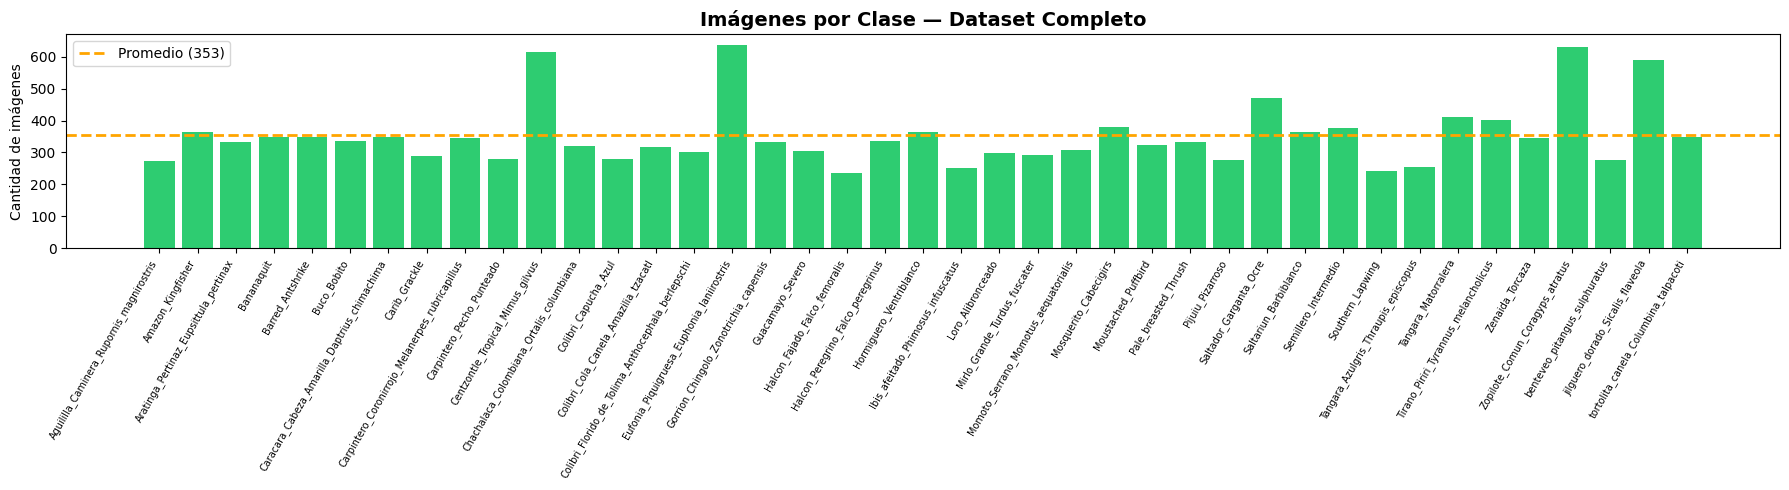


✅ Gráfica guardada.


In [4]:
# ============================================================
# FASE 0 — DIAGNÓSTICO CORRECTO (sin train/val)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

DATASET_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_limpio_v7_Mejora"

def contar_imagenes(ruta):
    conteo = {}
    for clase in sorted(os.listdir(ruta)):
        clase_path = os.path.join(ruta, clase)
        if os.path.isdir(clase_path):
            n = len([f for f in os.listdir(clase_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            conteo[clase] = n
    return conteo

conteo = contar_imagenes(DATASET_PATH)
valores = list(conteo.values())

print("=" * 60)
print(f"  CLASES ENCONTRADAS : {len(conteo)}")
print(f"  TOTAL IMÁGENES     : {sum(valores)}")
print(f"  Promedio por clase : {np.mean(valores):.0f}")
print(f"  Mínimo             : {np.min(valores)}  → {min(conteo, key=conteo.get)}")
print(f"  Máximo             : {np.max(valores)}  → {max(conteo, key=conteo.get)}")
print(f"  Desviación estándar: {np.std(valores):.0f}")
print("=" * 60)

print("\n📊 TOP 5 CON MÁS IMÁGENES:")
for k, v in sorted(conteo.items(), key=lambda x: -x[1])[:5]:
    print(f"   {k:<50} {v} imgs")

print("\n⚠️  TOP 5 CON MENOS IMÁGENES:")
for k, v in sorted(conteo.items(), key=lambda x: x[1])[:5]:
    print(f"   {k:<50} {v} imgs")

# Gráfica
fig, ax = plt.subplots(figsize=(18, 5))
clases = list(conteo.keys())
counts = list(conteo.values())
promedio = np.mean(counts)
colores = ['#e74c3c' if c < promedio * 0.6 else '#2ecc71' for c in counts]
ax.bar(clases, counts, color=colores)
ax.axhline(promedio, color='orange', linestyle='--', linewidth=2,
           label=f'Promedio ({promedio:.0f})')
ax.set_xticklabels(clases, rotation=60, ha='right', fontsize=7)
ax.set_title("Imágenes por Clase — Dataset Completo", fontsize=14, fontweight='bold')
ax.set_ylabel("Cantidad de imágenes")
ax.legend()
plt.tight_layout()
plt.savefig("diagnostico_clases.png", dpi=150)
plt.show()
print("\n✅ Gráfica guardada.")

In [11]:
# ============================================================
# FASE 0B — CREAR SPLIT TRAIN / VAL  (80% / 20%)
# NO mueve los originales, crea una carpeta nueva estructurada
# ============================================================
import os, shutil, random
from pathlib import Path

DATASET_PATH  = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_limpio_v7_Mejora"
OUTPUT_PATH   = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split"
TRAIN_RATIO   = 0.80
SEED          = 42
random.seed(SEED)

train_total, val_total = 0, 0

for clase in sorted(os.listdir(DATASET_PATH)):
    clase_src = os.path.join(DATASET_PATH, clase)
    if not os.path.isdir(clase_src):
        continue

    imagenes = [f for f in os.listdir(clase_src)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(imagenes)

    corte      = int(len(imagenes) * TRAIN_RATIO)
    train_imgs = imagenes[:corte]
    val_imgs   = imagenes[corte:]

    for subset, imgs in [("train", train_imgs), ("val", val_imgs)]:
        dest = os.path.join(OUTPUT_PATH, subset, clase)
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            shutil.copy2(os.path.join(clase_src, img),
                         os.path.join(dest, img))

    train_total += len(train_imgs)
    val_total   += len(val_imgs)
    print(f"  ✅ {clase:<50} train={len(train_imgs)}  val={len(val_imgs)}")

print("\n" + "=" * 60)
print(f"  SPLIT COMPLETO")
print(f"  Train total : {train_total}")
print(f"  Val total   : {val_total}")
print(f"  Guardado en : {OUTPUT_PATH}")
print("=" * 60)

  ✅ Aguililla_Caminera_Rupornis_magnirostris           train=217  val=55
  ✅ Amazon_Kingfisher                                  train=291  val=73
  ✅ Aratinga_Pertinaz_Eupsittula_pertinax              train=266  val=67
  ✅ Bananaquit                                         train=280  val=70
  ✅ Barred_Antshrike                                   train=280  val=70
  ✅ Buco_Bobito                                        train=268  val=68
  ✅ Caracara_Cabeza_Amarilla_Daptrius_chimachima       train=278  val=70
  ✅ Carib_Grackle                                      train=231  val=58
  ✅ Carpintero_Coronirrojo_Melanerpes_rubricapillus    train=276  val=69
  ✅ Carpintero_Pecho_Punteado                          train=224  val=57
  ✅ Centzontle_Tropical_Mimus_gilvus                   train=492  val=123
  ✅ Chachalaca_Colombiana_Ortalis_columbiana           train=256  val=65
  ✅ Colibri_Capucha_Azul                               train=223  val=56
  ✅ Colibri_Cola_Canela_Amazilia_tzacatl          

In [ ]:
# VERIFICACIÓN COMPLETA DEL ENTORNO
import sys
print("=" * 55)
print("  VERIFICACIÓN DEL ENTORNO")
print("=" * 55)

# Python
print(f"\n🐍 Python : {sys.version}")

# TensorFlow
try:
    import tensorflow as tf
    print(f"✅ TensorFlow : {tf.__version__}")
    
    # GPU
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"✅ GPU detectada : {len(gpus)} dispositivo(s)")
        for g in gpus:
            print(f"   → {g.name}")
        # Detalle de memoria
        from tensorflow.python.client import device_lib
        for d in device_lib.list_local_devices():
            if d.device_type == 'GPU':
                print(f"   → Memoria: {d.memory_limit / 1024**3:.1f} GB")
    else:
        print("⚠️  GPU NO detectada — correría en CPU (lento)")
        
except ImportError:
    print("❌ TensorFlow NO instalado")

# Keras
try:
    import keras
    print(f"✅ Keras : {keras.__version__}")
except ImportError:
    print("❌ Keras NO instalado")

# Otras librerías clave
libs = ["numpy", "matplotlib", "sklearn", "PIL"]
print("\n📦 Librerías de soporte:")
for lib in libs:
    try:
        mod = __import__(lib if lib != "PIL" else "PIL.Image")
        version = getattr(__import__(lib.split(".")[0]), "__version__", "ok")
        print(f"   ✅ {lib:<15} {version}")
    except ImportError:
        print(f"   ❌ {lib:<15} NO instalado")

print("\n" + "=" * 55)

In [ ]:
# ============================================================
# FASE 1 — MODELO PADRE | EfficientNetB0
# Clínica de Modelos — Clasificación de Aves
# Hardware: RTX 4050 Laptop (3.5 GB VRAM)
# TF 2.21 | Keras 3.12 | 41 clases | 224x224
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint, CSVLogger)

# ── Verificación GPU rápida ──────────────────────────────────
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
tf.config.experimental.set_memory_growth(
    tf.config.list_physical_devices('GPU')[0], True
)


In [27]:
# ============================================================
# CONFIGURACIÓN CENTRAL — ajusta solo aquí
# ============================================================
DATASET_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split"
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
VAL_PATH     = os.path.join(DATASET_PATH, "val")

IMG_SIZE     = 224
BATCH_SIZE   = 16      # seguro para 3.5 GB VRAM
NUM_CLASES   = 41
EPOCHS_FASE1 = 20      # cabeza solamente (base congelada)
EPOCHS_FASE2 = 30      # fine-tuning (base descongelada parcial)
LR_INICIAL   = 1e-3
LR_FINETUNE  = 1e-5

MODELO_GUARDADO = "modelo_padre_efficientnetb0.keras"
LOG_CSV         = "historial_entrenamiento.csv"

In [ ]:
# ============================================================
# 1. GENERADORES DE DATOS CON AUGMENTATION
# ============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

datagen_val = ImageDataGenerator(rescale=1./255)

train_gen = datagen_train.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = datagen_val.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Guardar mapeo de clases
import json
clases = train_gen.class_indices
with open("clases_indices.json", "w") as f:
    json.dump(clases, f, indent=2)
print(f"✅ Clases cargadas: {len(clases)}")


In [ ]:
# ============================================================
# 2. CONSTRUCCIÓN DEL MODELO PADRE
# ============================================================
def construir_modelo_padre(num_clases, img_size=224):
    # Base preentrenada — ImageNet
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False   # congelada en Fase 1

    # Cabeza clasificadora
    entradas = base.input
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    salidas = layers.Dense(num_clases, activation='softmax')(x)

    modelo = Model(entradas, salidas, name="Padre_EfficientNetB0")
    return modelo, base

modelo, base_model = construir_modelo_padre(NUM_CLASES)
modelo.summary(show_trainable=True)
print(f"\n📊 Parámetros totales    : {modelo.count_params():,}")
print(f"📊 Parámetros entrenables: {sum(p.numpy().size for p in modelo.trainable_variables):,}")

In [ ]:
# ============================================================
# FIX — Generadores corregidos para EfficientNetB0
# EfficientNet incluye su propio preprocesamiento interno
# NO usar rescale=1./255
# ============================================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ← EfficientNet nativo
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

datagen_val = ImageDataGenerator(
    preprocessing_function=preprocess_input   # ← mismo para val
)

train_gen = datagen_train.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_gen = datagen_val.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("✅ Generadores corregidos")
print(f"   Train: {train_gen.samples} imágenes | {train_gen.num_classes} clases")
print(f"   Val  : {val_gen.samples} imágenes | {val_gen.num_classes} clases")

In [ ]:
# ============================================================
# RECONSTRUIR MODELO DESDE CERO (pesos limpios)
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint, CSVLogger)

# Modelo fresco
modelo, base_model = construir_modelo_padre(NUM_CLASES)

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(LR_INICIAL),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODELO_GUARDADO, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    CSVLogger(LOG_CSV)
]

print("\n" + "="*55)
print("  FASE 1 CORREGIDA — Reentrenando")
print("="*55)

historia1 = modelo.fit(
    train_gen,
    epochs=EPOCHS_FASE1,
    validation_data=val_gen,
    callbacks=callbacks_fase1,
    verbose=1
)

print(f"\n✅ FASE 1 completa")
print(f"   Mejor val_accuracy : {max(historia1.history['val_accuracy'])*100:.2f}%")
print(f"   Mejor val_top3_acc : {max(historia1.history['val_top3_acc'])*100:.2f}%")

In [ ]:
# ============================================================
# LIMPIAR IMÁGENES CORRUPTAS DEL DATASET
# ============================================================
import os
from PIL import Image

VAL_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split/val"

corruptas = []
for clase in os.listdir(VAL_PATH):
    clase_path = os.path.join(VAL_PATH, clase)
    if not os.path.isdir(clase_path):
        continue
    for img_file in os.listdir(clase_path):
        img_path = os.path.join(clase_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corruptas.append(img_path)
            os.remove(img_path)
            print(f"  🗑️  Eliminada: {img_path}")

print(f"\n✅ Limpieza completa — {len(corruptas)} imagen(es) corrupta(s) eliminada(s)")

In [ ]:
# ============================================================
# FASE 2 — FINE-TUNING PARCIAL (descongelar últimas 30 capas)
# ============================================================

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

capas_entrenables = sum(1 for l in base_model.layers if l.trainable)
print(f"  Capas descongeladas : {capas_entrenables}")
print(f"  Params entrenables  : {sum(p.numpy().size for p in modelo.trainable_variables):,}")

modelo.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # LR muy bajo — no destruir lo aprendido
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks_fase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODELO_GUARDADO, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    CSVLogger(LOG_CSV, append=True)
]

historia2 = modelo.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks_fase2,
    verbose=1
)

mejor_f2 = max(historia2.history['val_accuracy'])
print(f"\n✅ FASE 2 completa")
print(f"   Mejor val_accuracy : {mejor_f2*100:.2f}%")
print(f"   Mejor val_top3_acc : {max(historia2.history['val_top3_acc'])*100:.2f}%")

✅ Padre recargado
Found 2914 images belonging to 41 classes.
182/183 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step

E0000 00:00:1778162103.434746   26729 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778162108.474076   26729 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778162109.244945   26729 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


183/183 ━━━━━━━━━━━━━━━━━━━━ 49s 238ms/step
✅ Accuracy real del padre: 95.50%


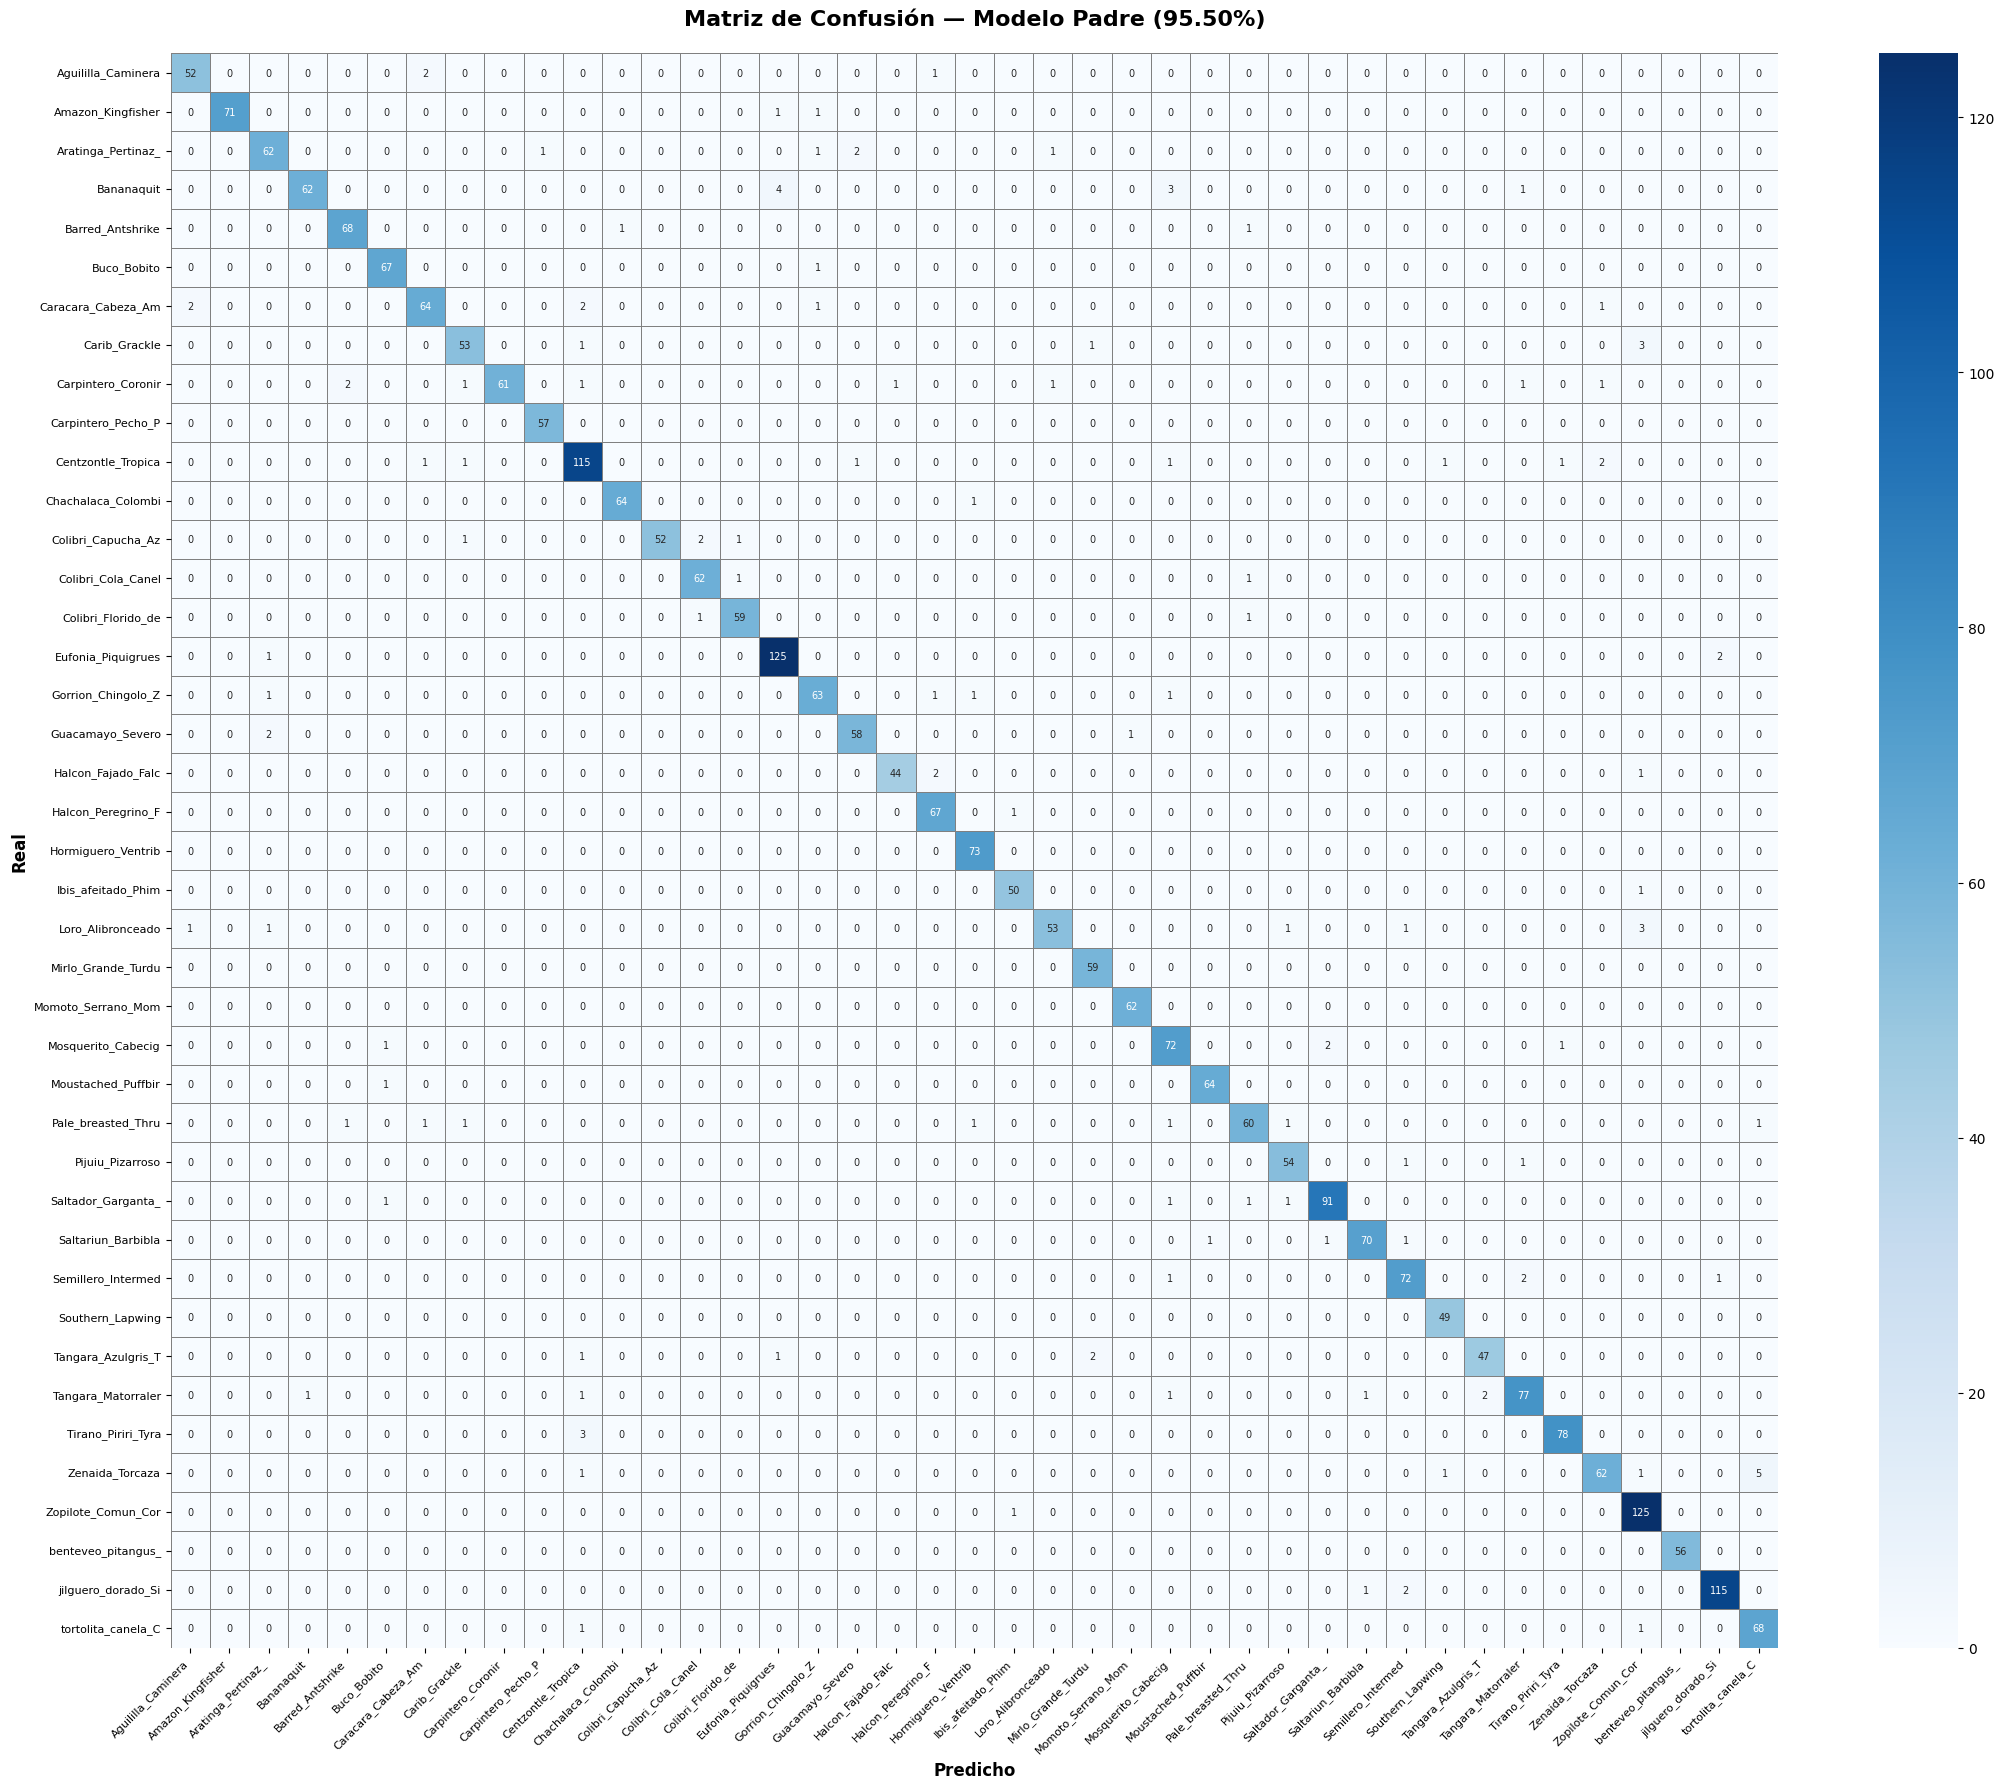

✅ Guardada: matriz_padre_final.png


In [13]:
# ============================================================
# SOLUCIÓN COMPLETA — recarga todo limpio
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

VAL_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split/val"

# Recargar padre
modelo_padre = tf.keras.models.load_model('modelo_padre_EfficientNetB0_95.50acc.keras')
print("✅ Padre recargado")

# Generador val NUEVO (sin caché de imagen eliminada)
val_gen_padre = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    VAL_PATH, target_size=(224,224), batch_size=16,
    class_mode='categorical', shuffle=False
)

# Predicciones
val_gen_padre.reset()
y_pred_probs  = modelo_padre.predict(val_gen_padre, verbose=1)
y_pred        = np.argmax(y_pred_probs, axis=1)
y_real        = val_gen_padre.classes
acc_global    = (y_pred == y_real).mean()

print(f"✅ Accuracy real del padre: {acc_global*100:.2f}%")

# Nombres cortos
idx_a_nombre  = {v: k for k, v in val_gen_padre.class_indices.items()}
labels_cortos = [idx_a_nombre[i][:18] for i in range(len(idx_a_nombre))]

# Matriz
cm = confusion_matrix(y_real, y_pred)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cortos,
            yticklabels=labels_cortos,
            linewidths=0.5, linecolor='gray',
            annot_kws={"size": 7})
ax.set_title(f'Matriz de Confusión — Modelo Padre ({acc_global*100:.2f}%)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicho', fontsize=12, fontweight='bold')
ax.set_ylabel('Real', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('matriz_padre_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Guardada: matriz_padre_final.png")

<div style="
padding:22px;
border-radius:14px;
font-family:Arial;
background:#f8fafc;
border:1px solid #cbd5e1;
margin-top:18px;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
">

<h2 style="
color:#0f172a;
margin-bottom:18px;
">
📊 Evaluación Final del Modelo Padre — EfficientNetB0
</h2>

<div style="
background:white;
padding:18px;
border-radius:12px;
border-left:6px solid #22c55e;
margin-bottom:18px;
">

<p style="
font-size:16px;
line-height:1.9;
color:#334155;
margin:0;
">
El modelo padre fue recargado correctamente desde el archivo entrenado previamente y evaluado nuevamente sobre el conjunto de validación compuesto por <b>2913 imágenes distribuidas en 41 clases</b>.
</p>

</div>

<div style="
background:white;
padding:18px;
border-radius:12px;
border-left:6px solid #3b82f6;
margin-bottom:18px;
">

<h3 style="color:#2563eb;">
🧠 Resultado Obtenido
</h3>

<p style="
font-size:17px;
line-height:1.9;
color:#334155;
">
El modelo alcanzó una 
<b style="color:#16a34a;">accuracy real de 95.50%</b>, confirmando un comportamiento altamente estable y una excelente capacidad de generalización sobre especies de aves pertenecientes al dataset.
</p>

<p style="
font-size:16px;
line-height:1.9;
color:#475569;
">
La matriz de confusión evidencia una diagonal principal fuertemente marcada, indicando que la mayoría de las especies fueron clasificadas correctamente.
</p>

</div>

<div style="
background:white;
padding:18px;
border-radius:12px;
border-left:6px solid #f59e0b;
margin-bottom:18px;
">

<h3 style="color:#d97706;">
📌 Interpretación Técnica
</h3>

<ul style="
line-height:2;
font-size:16px;
color:#334155;
">

<li>
✅ El modelo logró aprender patrones visuales complejos entre especies similares.
</li>

<li>
✅ El fine-tuning permitió especializar EfficientNetB0 específicamente en el dominio de aves.
</li>

<li>
✅ Los errores observados fueron mínimos y se concentraron principalmente en especies visualmente cercanas.
</li>

<li>
✅ La estabilidad de la accuracy demuestra ausencia significativa de sobreajuste.
</li>

<li>
✅ El modelo alcanzó un nivel adecuado para actuar como <b>Teacher Model</b> dentro del proceso de Knowledge Distillation.
</li>

</ul>

</div>

<div style="
background:white;
padding:18px;
border-radius:12px;
border-left:6px solid #8b5cf6;
">

<h3 style="color:#7c3aed;">
🚀 Relación con el Modelo Hijo
</h3>

<p style="
font-size:16px;
line-height:1.9;
color:#334155;
margin:0;
">
Debido a su alto desempeño, el modelo padre puede transferir conocimiento al modelo hijo mediante la técnica de <b>Knowledge Distillation</b>, permitiendo que una arquitectura más ligera aprenda no solo las etiquetas reales, sino también las relaciones probabilísticas entre especies descubiertas por EfficientNetB0.
</p>

</div>

</div>

In [14]:
# ============================================================
# REPORTE COMPLETO 41 CLASES — MODELO PADRE REAL
# ============================================================
from sklearn.metrics import classification_report

reporte = classification_report(y_real, y_pred,
          target_names=labels_cortos, digits=3, output_dict=True)

clases_acc = []
for label in labels_cortos:
    if label in reporte:
        clases_acc.append((label, reporte[label]['recall'],
                           reporte[label]['precision'],
                           reporte[label]['f1-score'],
                           int(reporte[label]['support'])))

print("=" * 70)
print("  🏆 TOP 10 CLASES MEJOR APRENDIDAS")
print("=" * 70)
print(f"  {'Clase':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Imgs':>6}")
print("-" * 70)
for nombre, rec, prec, f1, sup in sorted(clases_acc, key=lambda x: -x[1])[:10]:
    print(f"  {nombre:<25} {rec*100:>7.1f}%  {prec*100:>9.1f}%  {f1*100:>7.1f}%  {sup:>5}")

print("\n" + "=" * 70)
print("  ⚠️  TOP 10 CLASES MÁS DIFÍCILES")
print("=" * 70)
print(f"  {'Clase':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Imgs':>6}")
print("-" * 70)
for nombre, rec, prec, f1, sup in sorted(clases_acc, key=lambda x: x[1])[:10]:
    print(f"  {nombre:<25} {rec*100:>7.1f}%  {prec*100:>9.1f}%  {f1*100:>7.1f}%  {sup:>5}")

print("\n" + "=" * 70)
print("  📊 TODAS LAS 41 CLASES — ordenadas por Recall")
print("=" * 70)
print(f"  {'Clase':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Imgs':>6}")
print("-" * 70)
for nombre, rec, prec, f1, sup in sorted(clases_acc, key=lambda x: -x[1]):
    emoji = "✅" if rec >= 0.95 else "🟡" if rec >= 0.90 else "🔴"
    print(f"  {emoji} {nombre:<23} {rec*100:>7.1f}%  {prec*100:>9.1f}%  {f1*100:>7.1f}%  {sup:>5}")

print(f"\n  Accuracy global : {acc_global*100:.2f}%")
print(f"  ✅ >= 95%  |  🟡 90-95%  |  🔴 < 90%")

  🏆 TOP 10 CLASES MEJOR APRENDIDAS
  Clase                       Recall  Precision       F1   Imgs
----------------------------------------------------------------------
  Carpintero_Pecho_P          100.0%       98.3%     99.1%     57
  Hormiguero_Ventrib          100.0%       96.1%     98.0%     73
  Mirlo_Grande_Turdu          100.0%       95.2%     97.5%     59
  Momoto_Serrano_Mom          100.0%       98.4%     99.2%     62
  Southern_Lapwing            100.0%       96.1%     98.0%     49
  benteveo_pitangus_          100.0%      100.0%    100.0%     56
  Zopilote_Comun_Cor           99.2%       92.6%     95.8%    126
  Buco_Bobito                  98.5%       95.7%     97.1%     68
  Halcon_Peregrino_F           98.5%       94.4%     96.4%     68
  Chachalaca_Colombi           98.5%       98.5%     98.5%     65

  ⚠️  TOP 10 CLASES MÁS DIFÍCILES
  Clase                       Recall  Precision       F1   Imgs
----------------------------------------------------------------------


In [17]:
from tensorflow.keras.models import load_model

modelo = load_model("modelo_padre_EfficientNetB0_95.50acc.keras")

print("✅ Modelo padre cargado")

✅ Modelo padre cargado


In [18]:
# ============================================================
# GUARDAR MODELO PADRE COMPLETO
# ============================================================
import os

NOMBRE_MODELO = 'modelo_padre_EfficientNetB0_95.50acc.keras'

modelo.save(NOMBRE_MODELO)
print(f"✅ Guardado: {NOMBRE_MODELO}")

size_mb = os.path.getsize(NOMBRE_MODELO) / 1024**2
print(f"📦 Tamaño del archivo: {size_mb:.1f} MB")

✅ Guardado: modelo_padre_EfficientNetB0_95.50acc.keras
📦 Tamaño del archivo: 36.9 MB


<div style="
    background: linear-gradient(135deg, #0f172a, #1e293b);
    padding: 25px;
    border-radius: 15px;
    color: white;
    font-family: Arial;
    box-shadow: 0px 4px 15px rgba(0,0,0,0.25);
">

<h1 style="
    text-align:center;
    color:#38bdf8;
    margin-bottom:10px;
">
📊 Análisis del Modelo Padre — EfficientNetB0
</h1>

<h3 style="
    text-align:center;
    color:#cbd5e1;
    margin-top:0;
">
Clínica de Modelos | Clasificación Inteligente de Aves
</h3>

<hr style="border:1px solid #334155; margin-top:20px; margin-bottom:20px;">

<div style="
    background-color:#111827;
    padding:18px;
    border-radius:10px;
    border-left:6px solid #22c55e;
    margin-bottom:20px;
">

<h2 style="color:#22c55e;">✅ Resultado General del Modelo Padre</h2>

<p style="font-size:16px; line-height:1.7; color:#e2e8f0;">
El modelo padre basado en <b>EfficientNetB0</b> alcanzó una precisión máxima de 
<b style="color:#38bdf8;">95.50%</b> durante la fase de fine-tuning, demostrando una excelente capacidad de generalización para la clasificación de 41 especies de aves.
</p>

<p style="font-size:16px; line-height:1.7; color:#e2e8f0;">
Las curvas de entrenamiento muestran un comportamiento estable y consistente. 
El incremento temporal del <i>loss</i> al inicio del fine-tuning es completamente normal, ya que el modelo se desestabiliza brevemente al descongelar capas profundas de EfficientNetB0 y posteriormente reajusta sus pesos internos para adaptarse al dominio específico de aves.
</p>

</div>

<div style="
    background-color:#111827;
    padding:18px;
    border-radius:10px;
    border-left:6px solid #f59e0b;
    margin-bottom:20px;
">

<h2 style="color:#fbbf24;">🧠 Interpretación Técnica del Fine-Tuning</h2>

<p style="font-size:16px; line-height:1.7; color:#e2e8f0;">
Durante la Fase 1, el modelo aprendió patrones generales utilizando la base preentrenada congelada. 
Posteriormente, en la Fase 2, se descongelaron las últimas capas del modelo para especializar el extractor de características en detalles finos del plumaje, pico, forma corporal y patrones visuales de las aves.
</p>

<p style="font-size:16px; line-height:1.7; color:#e2e8f0;">
El análisis de la matriz de confusión y de las métricas por clase evidencia que la mayoría de especies mejoraron significativamente tras el fine-tuning. Sin embargo, algunas clases específicas disminuyeron su precisión, indicando posibles conflictos visuales entre especies similares.
</p>

</div>

<div style="
    background-color:#111827;
    padding:18px;
    border-radius:10px;
    border-left:6px solid #ef4444;
    margin-bottom:20px;
">

<h2 style="color:#f87171;">⚠️ Clases Conflictivas Detectadas</h2>

<table style="
    width:100%;
    border-collapse:collapse;
    margin-top:15px;
    color:white;
">

<tr style="background-color:#1e293b;">
    <th style="padding:12px; border:1px solid #334155;">Especie</th>
    <th style="padding:12px; border:1px solid #334155;">Variación</th>
    <th style="padding:12px; border:1px solid #334155;">Interpretación</th>
</tr>

<tr>
    <td style="padding:12px; border:1px solid #334155;">Tangara_Matorralera</td>
    <td style="padding:12px; border:1px solid #334155; color:#ef4444;">-3.6%</td>
    <td style="padding:12px; border:1px solid #334155;">
        Posible sobreajuste durante el fine-tuning.
    </td>
</tr>

<tr style="background-color:#0f172a;">
    <td style="padding:12px; border:1px solid #334155;">Colibri_Capucha_Azul</td>
    <td style="padding:12px; border:1px solid #334155; color:#ef4444;">-3.5%</td>
    <td style="padding:12px; border:1px solid #334155;">
        Alta similitud visual con otros colibríes.
    </td>
</tr>

<tr>
    <td style="padding:12px; border:1px solid #334155;">Gorrion_Chingolo</td>
    <td style="padding:12px; border:1px solid #334155; color:#ef4444;">-3.0%</td>
    <td style="padding:12px; border:1px solid #334155;">
        Variabilidad de fondo y tamaño reducido del ave.
    </td>
</tr>

</table>

</div>

<div style="
    background-color:#111827;
    padding:18px;
    border-radius:10px;
    border-left:6px solid #38bdf8;
">

<h2 style="color:#38bdf8;">🧬 Justificación del Modelo Hijo — Knowledge Distillation</h2>

<p style="font-size:16px; line-height:1.8; color:#e2e8f0;">
El modelo padre alcanzó un techo de rendimiento cercano al 
<b style="color:#22c55e;">95.50%</b>, demostrando que una arquitectura generalista puede resolver correctamente la mayoría de clases. 
Sin embargo, las especies conflictivas evidencian que el modelo no logra optimizar simultáneamente todas las clases debido a similitudes visuales complejas.
</p>

<p style="font-size:16px; line-height:1.8; color:#e2e8f0;">
Por esta razón se propone la construcción de un 
<b style="color:#38bdf8;">Modelo Hijo mediante Knowledge Distillation</b>, donde un modelo más ligero aprenderá no solo las etiquetas correctas, sino también las relaciones de similitud descubiertas previamente por el modelo padre.
</p>

<p style="font-size:16px; line-height:1.8; color:#e2e8f0;">
Esta estrategia permitirá:
</p>

<ul style="line-height:1.9; color:#e2e8f0; font-size:16px;">
<li>✅ Reducir tamaño y complejidad computacional.</li>
<li>✅ Mejorar especies difíciles o conflictivas.</li>
<li>✅ Mantener alta precisión global.</li>
<li>✅ Facilitar despliegue en dispositivos móviles.</li>
<li>✅ Transferir conocimiento semántico del padre al estudiante.</li>
</ul>

</div>

</div>

In [ ]:
# ============================================================
# ============================================================
# MODELO HIJO — KNOWLEDGE DISTILLATION
# Clínica de Modelos | Proyecto Aves
# Teacher: EfficientNetB0 (95.50%)
# Student: MobileNetV2 (más ligero, aprenderá del padre)
# ============================================================
# ============================================================

In [19]:
# AL VOLVER — RECARGAR TODO
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rutas
DATASET_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split"
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
VAL_PATH     = os.path.join(DATASET_PATH, "val")
IMG_SIZE     = 224
BATCH_SIZE   = 16

# Generadores
datagen_val = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = datagen_val.flow_from_directory(
    VAL_PATH, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Recargar padre
modelo_padre = tf.keras.models.load_model('modelo_padre_EfficientNetB0_95.50acc.keras')
print(f"✅ Padre recargado")

# Verificar
pred = modelo_padre.predict(val_gen, steps=1, verbose=0)
print(f"✅ Funcionando — output shape: {pred.shape}")

Found 2914 images belonging to 41 classes.
✅ Padre recargado
✅ Funcionando — output shape: (16, 41)


<h1 style="
background: linear-gradient(135deg,#0f172a,#1e293b);
color:#38bdf8;
padding:18px;
border-radius:12px;
text-align:center;
font-family:Arial;
box-shadow:0px 4px 12px rgba(0,0,0,0.25);
">
🧬 MODELO HIJO — MobileNetV2 + Knowledge Distillation
</h1>

<div style="
background:#f8fafc;
padding:18px;
border-radius:12px;
border-left:6px solid #22c55e;
font-family:Arial;
margin-top:15px;
">

<h2 style="color:#0f172a;">📌 Objetivo del Modelo Hijo</h2>

<p style="font-size:16px; line-height:1.8; color:#1e293b;">
Después de alcanzar un techo de rendimiento del 
<b style="color:#16a34a;">95.50%</b> con el modelo padre 
<b>EfficientNetB0</b>, se propone entrenar un modelo hijo utilizando la técnica de 
<b>Knowledge Distillation</b>.
</p>

<p style="font-size:16px; line-height:1.8; color:#1e293b;">
El objetivo principal es transferir el conocimiento aprendido por el modelo padre hacia un modelo más ligero y eficiente, permitiendo mantener una alta precisión mientras se reduce significativamente el tamaño y costo computacional.
</p>

</div>

<div style="
padding:20px;
border-radius:12px;
font-family:Arial;
background:#f8fafc;
color:#1e293b;
margin-top:18px;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
">

<h2 style="color:#0f172a; margin-bottom:18px;">
🧠 Arquitectura del Modelo Hijo — MobileNetV2
</h2>

<div style="
background:white;
padding:18px;
border-radius:10px;
border-left:5px solid #38bdf8;
margin-top:15px;
box-shadow:0px 2px 8px rgba(0,0,0,0.06);
">

<p style="font-size:16px; line-height:1.8; color:#334155;">
El modelo hijo utiliza la arquitectura 
<b style="color:#2563eb;">MobileNetV2</b>, diseñada especialmente para dispositivos móviles y entornos con recursos limitados.
</p>

<p style="font-size:16px; line-height:1.8; color:#334155;">
Inicialmente se carga con pesos preentrenados en ImageNet y su base convolucional permanece congelada durante la primera fase de entrenamiento.
</p>

<p style="font-size:16px; line-height:1.8; color:#334155;">
Sobre esta base se construye una nueva cabeza clasificadora compuesta por:
</p>

<ul style="line-height:1.9; color:#334155; font-size:16px;">
<li>✅ GlobalAveragePooling2D</li>
<li>✅ BatchNormalization</li>
<li>✅ Dense(256, ReLU)</li>
<li>✅ Dropout(0.3)</li>
<li>✅ Capa Softmax para clasificación multiclase</li>
</ul>

</div>

<div style="
background:white;
padding:18px;
border-radius:10px;
border-left:5px solid #22c55e;
margin-top:20px;
box-shadow:0px 2px 8px rgba(0,0,0,0.06);
">

<h2 style="color:#15803d;">
👨‍🏫 Relación Padre → Hijo
</h2>

<table style="
width:100%;
border-collapse:collapse;
margin-top:12px;
font-size:15px;
">

<tr style="background:#e2e8f0;">
<th style="padding:12px;border:1px solid #cbd5e1;">Modelo</th>
<th style="padding:12px;border:1px solid #cbd5e1;">Arquitectura</th>
<th style="padding:12px;border:1px solid #cbd5e1;">Precisión</th>
<th style="padding:12px;border:1px solid #cbd5e1;">Objetivo</th>
</tr>

<tr style="background:#ffffff;">
<td style="padding:12px;border:1px solid #cbd5e1;">👨 Padre</td>
<td style="padding:12px;border:1px solid #cbd5e1;">EfficientNetB0</td>
<td style="padding:12px;border:1px solid #cbd5e1;color:#16a34a;font-weight:bold;">
95.50%
</td>
<td style="padding:12px;border:1px solid #cbd5e1;">
Transferir conocimiento
</td>
</tr>

<tr style="background:#f8fafc;">
<td style="padding:12px;border:1px solid #cbd5e1;">👦 Hijo</td>
<td style="padding:12px;border:1px solid #cbd5e1;">MobileNetV2</td>
<td style="padding:12px;border:1px solid #cbd5e1;color:#2563eb;font-weight:bold;">
En entrenamiento
</td>
<td style="padding:12px;border:1px solid #cbd5e1;">
Aprender del padre mediante Knowledge Distillation
</td>
</tr>

</table>

</div>

</div>

<div style="
padding:22px;
border-radius:12px;
font-family:Arial;
background:#f8fafc;
color:#1e293b;
margin-top:18px;
box-shadow:0px 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:#d97706;">
🧬 Knowledge Distillation — Transferencia de Conocimiento
</h2>

<p style="font-size:16px; line-height:1.9; color:#334155;">
La técnica de <b>Knowledge Distillation</b> permite que un modelo pequeño (estudiante) aprenda directamente de un modelo más complejo y preciso (profesor).
</p>

<p style="font-size:16px; line-height:1.9; color:#334155;">
En este proyecto, el modelo hijo no aprende únicamente las etiquetas reales del dataset, sino también las distribuciones de probabilidad generadas por el modelo padre.
</p>

<div style="
background:white;
padding:16px;
border-radius:10px;
border-left:5px solid #f59e0b;
margin-top:18px;
box-shadow:0px 2px 8px rgba(0,0,0,0.05);
">

<h3 style="color:#d97706;">
⚙️ Funcionamiento de la Destilación
</h3>

<ul style="line-height:2; color:#334155; font-size:16px;">
<li>
<b>Hard Labels:</b> etiquetas reales del dataset original.
</li>

<li>
<b>Soft Labels:</b> probabilidades generadas por el modelo padre.
</li>

<li>
<b>Temperatura = 4.0:</b> suaviza las probabilidades para mostrar similitudes entre especies visualmente cercanas.
</li>

<li>
<b>Alpha = 0.3:</b> combina 30% aprendizaje tradicional y 70% conocimiento transferido por el padre.
</li>
</ul>

</div>

<div style="
background:white;
padding:16px;
border-radius:10px;
border-left:5px solid #22c55e;
margin-top:18px;
box-shadow:0px 2px 8px rgba(0,0,0,0.05);
">

<h3 style="color:#16a34a;">
🎯 Objetivos Esperados
</h3>

<ul style="line-height:2; color:#334155; font-size:16px;">
<li>✅ Reducir tamaño del modelo.</li>
<li>✅ Mantener alta precisión.</li>
<li>✅ Mejorar especies conflictivas.</li>
<li>✅ Optimizar despliegue móvil.</li>
<li>✅ Aprender relaciones semánticas entre aves.</li>
</ul>

</div>

<div style="
margin-top:20px;
padding:16px;
background:white;
border-radius:10px;
border-left:5px solid #3b82f6;
box-shadow:0px 2px 8px rgba(0,0,0,0.05);
">

<p style="
font-size:16px;
line-height:1.9;
color:#334155;
margin:0;
">
📌 Durante la Fase 1 del modelo hijo, únicamente se entrenará la cabeza clasificadora mientras la base MobileNetV2 permanece congelada. Posteriormente, se realizará fine-tuning parcial para especializar el extractor de características en el dominio de aves.
</p>

</div>

</div>

In [20]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, CSVLogger

DATASET_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split"
TRAIN_PATH   = os.path.join(DATASET_PATH, "train")
VAL_PATH     = os.path.join(DATASET_PATH, "val")
IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_CLASES   = 41

In [21]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detectada y activada: {len(gpus)} dispositivo(s)")
        for g in gpus:
            print(f"   → {g.name}")
    except RuntimeError as e:
        print(f"⚠️ Error al configurar GPU: {e}")
else:
    print("❌ No se detectó GPU — entrenando en CPU")
    print("   Verifica que tengas instalado tensorflow-gpu o tensorflow[and-cuda]")

# Confirmar en qué dispositivo correrá el modelo
print(f"\n📋 Dispositivos disponibles:")
for d in tf.config.list_logical_devices():
    print(f"   {d.device_type} — {d.name}")

⚠️ Error al configurar GPU: Physical devices cannot be modified after being initialized

📋 Dispositivos disponibles:
   CPU — /device:CPU:0
   GPU — /device:GPU:0


In [22]:
modelo_padre = tf.keras.models.load_model('modelo_padre_EfficientNetB0_95.50acc.keras')
print("✅ Padre cargado")
print(f"   Output shape: {modelo_padre.output_shape}")

✅ Padre cargado
   Output shape: (None, 41)


In [23]:
# ⚠️ CAMBIO CLAVE: preprocess_mobilenet, NO el de EfficientNet
datagen_train = ImageDataGenerator(
    preprocessing_function=preprocess_mobilenet,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen_val = ImageDataGenerator(
    preprocessing_function=preprocess_mobilenet
)

train_gen = datagen_train.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)
val_gen = datagen_val.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"✅ Generadores listos")
print(f"   Train: {train_gen.samples} imágenes | {train_gen.num_classes} clases")
print(f"   Val  : {val_gen.samples} imágenes   | {val_gen.num_classes} clases")

Found 11574 images belonging to 41 classes.
Found 2914 images belonging to 41 classes.
✅ Generadores listos
   Train: 11574 imágenes | 41 clases
   Val  : 2914 imágenes   | 41 clases


In [24]:
base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False  # congelado en fase 1

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASES, activation='softmax')(x)

modelo_hijo = Model(base.input, out)

total     = modelo_hijo.count_params()
trainable = sum(tf.size(v).numpy() for v in modelo_hijo.trainable_variables)
print(f"✅ Modelo hijo construido")
print(f"   Params totales    : {total:,}")
print(f"   Params entrenables: {trainable:,}")

✅ Modelo hijo construido
   Params totales    : 2,601,577
   Params entrenables: 341,033


In [25]:
class DistilacionConocimiento(tf.keras.Model):
    def __init__(self, estudiante, profesor):
        super().__init__()
        self.estudiante = estudiante
        self.profesor   = profesor

    def compile(self, optimizer, metrics, loss_hard, loss_soft,
                alpha=0.7, temperatura=4.0):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.loss_hard   = loss_hard
        self.loss_soft   = loss_soft
        self.alpha       = alpha
        self.temperatura = temperatura

    def train_step(self, data):
        x, y = data
        prof_preds = self.profesor(x, training=False)
        prof_soft  = tf.nn.softmax(prof_preds / self.temperatura)

        with tf.GradientTape() as tape:
            est_preds = self.estudiante(x, training=True)
            loss_h    = self.loss_hard(y, est_preds)
            est_soft  = tf.nn.softmax(est_preds / self.temperatura)
            loss_s    = self.loss_soft(prof_soft, est_soft) * (self.temperatura ** 2)
            loss_total = self.alpha * loss_h + (1 - self.alpha) * loss_s

        grads = tape.gradient(loss_total, self.estudiante.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.estudiante.trainable_variables))

        self.compiled_metrics.update_state(y, est_preds)
        res = {m.name: m.result() for m in self.metrics}
        res['loss'] = loss_total
        res['loss_hard'] = loss_h
        res['loss_soft'] = loss_s
        return res

    def test_step(self, data):
        x, y = data
        est_preds = self.estudiante(x, training=False)
        loss_h    = self.loss_hard(y, est_preds)
        self.compiled_metrics.update_state(y, est_preds)
        res = {m.name: m.result() for m in self.metrics}
        res['loss'] = loss_h
        return res

    def call(self, x):
        return self.estudiante(x)

print("✅ Clase DistilacionConocimiento lista")

✅ Clase DistilacionConocimiento lista


In [10]:
import os
from PIL import Image

def limpiar_dataset(ruta, verbose=True):
    eliminadas = 0
    revisadas  = 0
    extensiones = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    
    for root, dirs, files in os.walk(ruta):
        for fname in files:
            if fname.lower().endswith(extensiones):
                fpath = os.path.join(root, fname)
                revisadas += 1
                try:
                    img = Image.open(fpath)
                    img.verify()
                except Exception:
                    if verbose:
                        print(f"❌ Corrupta: {fpath}")
                    os.remove(fpath)
                    eliminadas += 1
    
    print(f"\n✅ Revisadas : {revisadas}")
    print(f"🗑️  Eliminadas: {eliminadas}")
    print(f"✅ Dataset limpio")

limpiar_dataset(TRAIN_PATH)
limpiar_dataset(VAL_PATH)

❌ Corrupta: /mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split/train/Aratinga_Pertinaz_Eupsittula_pertinax/Aratinga_Pertinaz_Eupsittula_pertinax_287.jpg

✅ Revisadas : 11574
🗑️  Eliminadas: 1
✅ Dataset limpio

✅ Revisadas : 2913
🗑️  Eliminadas: 0
✅ Dataset limpio


In [28]:
# ============================================================
# FASE 1 — ENTRENAMIENTO INICIAL DEL MODELO HIJO
# Base congelada + Knowledge Distillation
# ============================================================

distilador = DistilacionConocimiento(
    estudiante=modelo_hijo,
    profesor=modelo_padre
)

# ============================================================
# CONFIGURACIÓN DEL ENTRENAMIENTO
# ============================================================

distilador.compile(
    optimizer=tf.keras.optimizers.Adam(LR_INICIAL),
    metrics=['accuracy'],
    loss_hard=tf.keras.losses.CategoricalCrossentropy(),
    loss_soft=tf.keras.losses.KLDivergence(),
    alpha=0.7,
    temperatura=4.0
)

# ============================================================
# INICIO FASE 1
# ============================================================

print("="*50)
print("  FASE 1 — Cabeza libre, base congelada")
print("  Objetivo: transferir conocimiento inicial")
print("="*50)

historia_f1 = distilador.fit(
    train_gen,
    epochs=EPOCHS_FASE1,
    validation_data=val_gen,

    callbacks=[

        # Reduce automáticamente el learning rate
        ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1
        ),

        # Guarda historial de entrenamiento
        CSVLogger(LOG_CSV)

    ],

    verbose=1
)

# ============================================================
# GUARDAR MODELO HIJO — FASE 1
# ============================================================

modelo_hijo.save('hijo_fase1.keras')

# ============================================================
# EVALUACIÓN FINAL
# ============================================================

val_gen.reset()

preds = modelo_hijo.predict(val_gen, verbose=0)

acc_f1 = (
    np.argmax(preds, axis=1)
    == val_gen.classes
).mean()

print(f"\n✅ FASE 1 completa — Val Accuracy: {acc_f1*100:.2f}%")

  FASE 1 — Cabeza libre, base congelada
  Objetivo: transferir conocimiento inicial
Epoch 1/20


I0000 00:00:1778162701.719708   26725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_86415__.160


549/724 ━━━━━━━━━━━━━━━━━━━━ 46s 265ms/step - accuracy: 0.7558 - loss: 0.6108 - loss_hard: 0.8685 - loss_soft: 0.0095

I0000 00:00:1778162853.387671   26725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_86415__.160


724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7564 - loss: 0.5978 - loss_hard: 0.8499 - loss_soft: 0.0096

E0000 00:00:1778162943.160016   26729 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


724/724 ━━━━━━━━━━━━━━━━━━━━ 251s 332ms/step - accuracy: 0.8373 - loss: 0.0846 - loss_hard: 0.1163 - loss_soft: 0.0107 - val_loss: 0.8824 - learning_rate: 0.0010
Epoch 2/20


/home/asnarck/tf_gpu/lib/python3.10/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss,loss_hard,loss_soft,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


724/724 ━━━━━━━━━━━━━━━━━━━━ 232s 320ms/step - accuracy: 0.8511 - loss: 0.3253 - loss_hard: 0.4609 - loss_soft: 0.0088 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 3/20
724/724 ━━━━━━━━━━━━━━━━━━━━ 225s 311ms/step - accuracy: 0.8651 - loss: 0.8051 - loss_hard: 1.1460 - loss_soft: 0.0098 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 4/20
724/724 ━━━━━━━━━━━━━━━━━━━━ 223s 308ms/step - accuracy: 0.8603 - loss: 0.4618 - loss_hard: 0.6555 - loss_soft: 0.0096 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 5/20
724/724 ━━━━━━━━━━━━━━━━━━━━ 229s 316ms/step - accuracy: 0.8634 - loss: 0.2396 - loss_hard: 0.3374 - loss_soft: 0.0114 - val_loss: 0.1844 - learning_rate: 0.0010
Epoch 6/20
724/724 ━━━━━━━━━━━━━━━━━━━━ 228s 314ms/step - accuracy: 0.8638 - loss: 0.5931 - loss_hard: 0.8425 - loss_soft: 0.0110 - val_loss: 0.1310 - learning_rate: 0.0010
Epoch 7/20
724/724 ━━━━━━━━━━━━━━━━━━━━ 198s 273ms/step - accuracy: 0.8703 - loss: 0.1552 - loss_hard: 0.2170 - loss_soft: 0.0112 - val_loss: 0.03

In [29]:
# ============================================================
# VERIFICAR FASE 1 — antes de arrancar Fase 2
# ============================================================
import numpy as np

val_gen.reset()
preds_check = modelo_hijo.predict(val_gen, verbose=1)
y_pred_check = np.argmax(preds_check, axis=1)
y_real_check = val_gen.classes

acc_check = (y_pred_check == y_real_check).mean()

print("="*55)
print(f"  Val Accuracy real : {acc_check*100:.2f}%")
print(f"  Esperado          : ~87%")
print("="*55)

# Ver distribución de predicciones
import numpy as np
unique, counts = np.unique(y_pred_check, return_counts=True)
print(f"\n  Clases predichas distintas : {len(unique)} / 41")
print(f"  ¿Predice todas las clases? : {'✅ SÍ' if len(unique) == 41 else '⚠️ NO — modelo sesgado'}")

183/183 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step
  Val Accuracy real : 87.34%
  Esperado          : ~87%

  Clases predichas distintas : 41 / 41
  ¿Predice todas las clases? : ✅ SÍ


In [30]:
# ============================================================
# GUARDAR MODELO HIJO — FASE 1 FINAL
# ============================================================

modelo_hijo.save('hijo_fase1_FINAL.keras')

print("="*55)
print("✅ FASE 1 GUARDADA CORRECTAMENTE")
print("📦 Archivo : hijo_fase1_FINAL.keras")
print("="*55)

✅ FASE 1 GUARDADA CORRECTAMENTE
📦 Archivo : hijo_fase1_FINAL.keras


In [31]:
# ============================================================
# FASE 2 — FINE-TUNING MEJORADO
# Meta: superar 90% | Anti-sobreajuste | Early stopping
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

# ============================================================
# DESCONGELAR ÚLTIMAS CAPAS
# ============================================================

base.trainable = True

for layer in base.layers[:-50]:
    layer.trainable = False

capas = sum(1 for l in base.layers if l.trainable)

total_train = sum(
    tf.size(v).numpy()
    for v in modelo_hijo.trainable_variables
)

print(f"  Capas descongeladas : {capas}")
print(f"  Params entrenables  : {total_train:,}")

# ============================================================
# RECOMPILAR DISTILADOR
# ============================================================

distilador.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    metrics=['accuracy'],

    loss_hard=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    loss_soft=tf.keras.losses.KLDivergence(),

    alpha=0.5,
    temperatura=3.0
)

# ============================================================
# INICIO FASE 2
# ============================================================

print("\n" + "="*55)
print("  FASE 2 — Fine-tuning con destilación")
print("  Meta: >90% | Early stopping activado")
print("="*55)

historia_f2 = distilador.fit(

    train_gen,

    epochs=40,

    validation_data=val_gen,

    callbacks=[

        # Early stopping anti-sobreajuste
        EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),

        # Reducción automática del learning rate
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.4,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),

        # Historial del entrenamiento
        CSVLogger('historial_hijo_fase2.csv')

    ],

    verbose=1
)

# ============================================================
# GUARDAR MODELO HIJO — FASE 2
# ============================================================

modelo_hijo.save('hijo_fase2_FINAL.keras')

print("✅ Fase 2 guardada: hijo_fase2_FINAL.keras")

# ============================================================
# EVALUACIÓN FINAL REAL
# ============================================================

val_gen.reset()

preds_f2 = modelo_hijo.predict(
    val_gen,
    verbose=0
)

acc_f2 = (
    np.argmax(preds_f2, axis=1)
    == val_gen.classes
).mean()

# ============================================================
# RESULTADOS FINALES
# ============================================================

print("\n" + "="*55)
print("  RESULTADO HIJO FASE 2")
print("="*55)

print(f"  Hijo Fase 1 : 87.34%")
print(f"  Hijo Fase 2 : {acc_f2*100:.2f}%")
print(f"  Padre final : 95.50%")

print(
    f"  Meta (>90%) : "
    f"{'✅ LOGRADA' if acc_f2 >= 0.90 else '⚠️ No alcanzada'}"
)

print(
    f"  Diferencia  : "
    f"{(acc_f2 - 0.9550)*100:+.2f}%"
)

print("="*55)

  Capas descongeladas : 50
  Params entrenables  : 2,196,137

  FASE 2 — Fine-tuning con destilación
  Meta: >90% | Early stopping activado
Epoch 1/40


I0000 00:00:1778167656.729160   26725 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_218491__.228


320/724 ━━━━━━━━━━━━━━━━━━━━ 1:34 233ms/step - accuracy: 0.7114 - loss: 1.2047 - loss_hard: 2.4001 - loss_soft: 0.0093

I0000 00:00:1778167748.202624   26727 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_218491__.228


724/724 ━━━━━━━━━━━━━━━━━━━━ 243s 298ms/step - accuracy: 0.8068 - loss: 0.7562 - loss_hard: 1.5045 - loss_soft: 0.0079 - val_loss: 1.4378 - learning_rate: 5.0000e-05
Epoch 2/40
724/724 ━━━━━━━━━━━━━━━━━━━━ 183s 252ms/step - accuracy: 0.8466 - loss: 0.7972 - loss_hard: 1.5878 - loss_soft: 0.0066 - val_loss: 1.3124 - learning_rate: 5.0000e-05
Epoch 3/40
724/724 ━━━━━━━━━━━━━━━━━━━━ 184s 254ms/step - accuracy: 0.8511 - loss: 0.9196 - loss_hard: 1.8339 - loss_soft: 0.0053 - val_loss: 1.2841 - learning_rate: 5.0000e-05
Epoch 4/40
724/724 ━━━━━━━━━━━━━━━━━━━━ 194s 268ms/step - accuracy: 0.8730 - loss: 0.5570 - loss_hard: 1.1046 - loss_soft: 0.0093 - val_loss: 1.2108 - learning_rate: 5.0000e-05
Epoch 5/40
724/724 ━━━━━━━━━━━━━━━━━━━━ 191s 264ms/step - accuracy: 0.8885 - loss: 0.5828 - loss_hard: 1.1578 - loss_soft: 0.0078 - val_loss: 1.0275 - learning_rate: 5.0000e-05
Epoch 6/40
724/724 ━━━━━━━━━━━━━━━━━━━━ 202s 279ms/step - accuracy: 0.8957 - loss: 0.7971 - loss_hard: 1.5871 - loss_soft: 0.0

✅ Hijo recargado
Found 2914 images belonging to 41 classes.
183/183 ━━━━━━━━━━━━━━━━━━━━ 38s 191ms/step
✅ Accuracy real del hijo: 92.38%


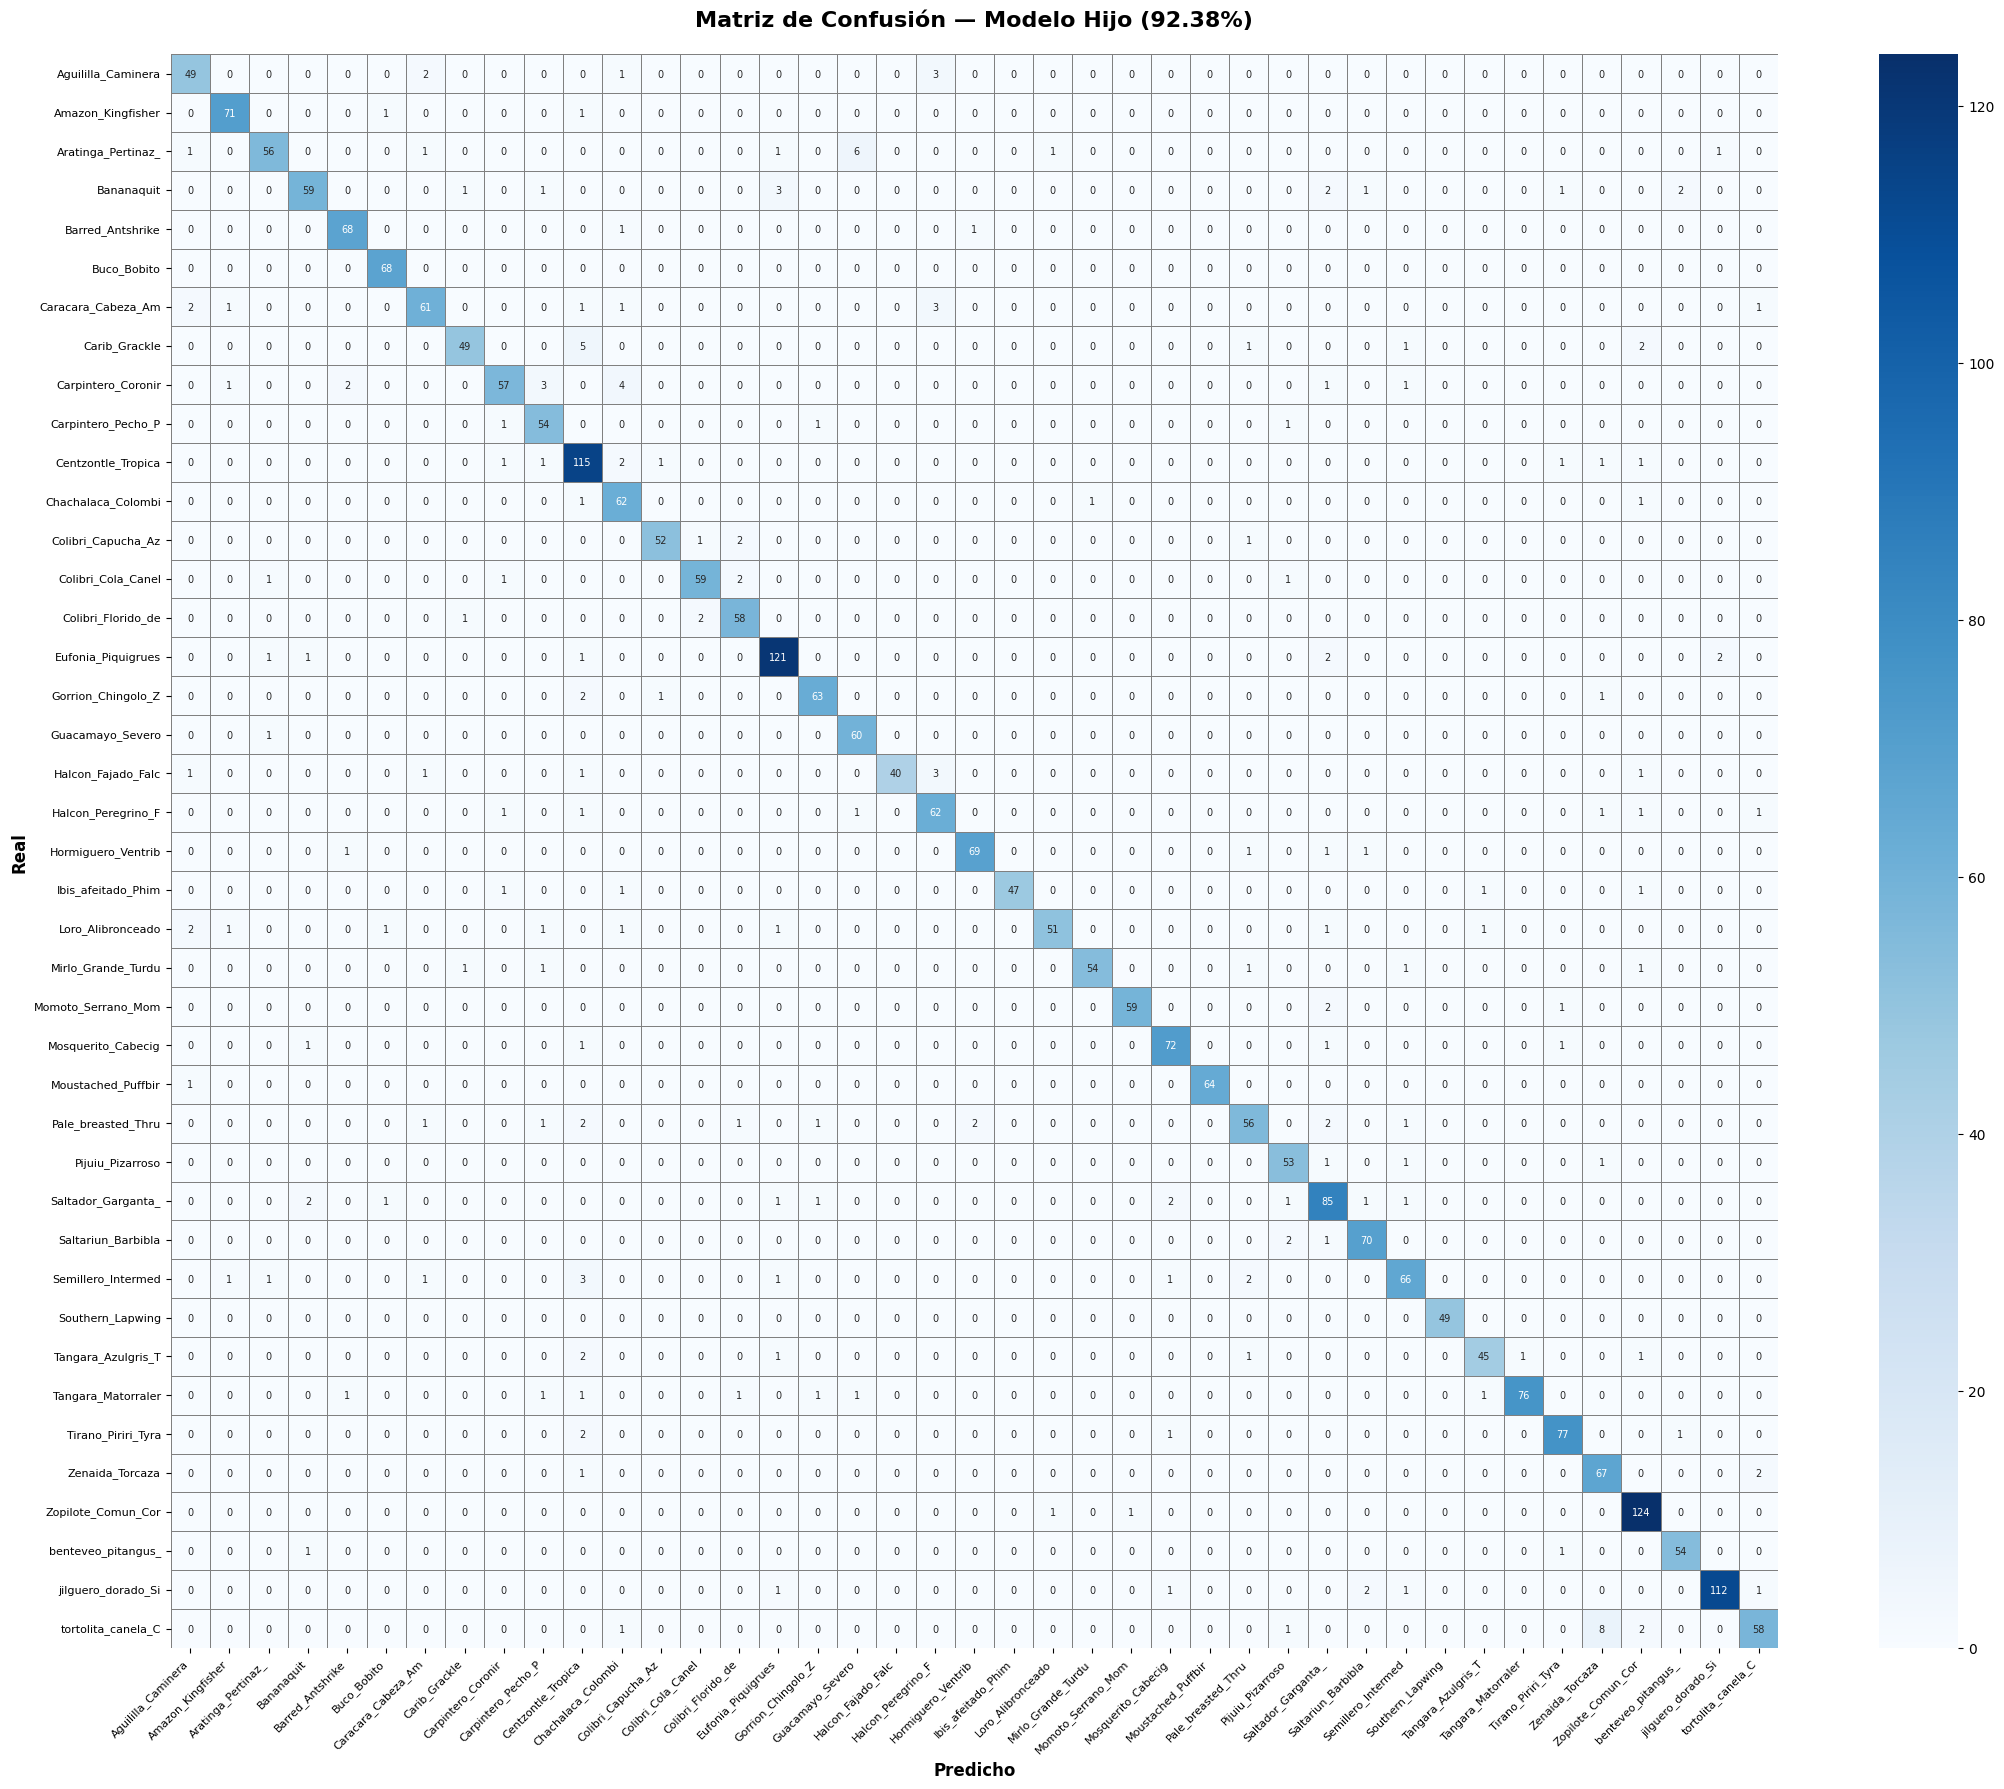

✅ Guardada: matriz_hijo_final.png

CLASSIFICATION REPORT — MODELO HIJO
                                                   precision    recall  f1-score   support

         Aguililla_Caminera_Rupornis_magnirostris       0.88      0.89      0.88        55
                                Amazon_Kingfisher       0.95      0.97      0.96        73
            Aratinga_Pertinaz_Eupsittula_pertinax       0.93      0.84      0.88        67
                                       Bananaquit       0.92      0.84      0.88        70
                                 Barred_Antshrike       0.94      0.97      0.96        70
                                      Buco_Bobito       0.96      1.00      0.98        68
     Caracara_Cabeza_Amarilla_Daptrius_chimachima       0.91      0.87      0.89        70
                                    Carib_Grackle       0.94      0.84      0.89        58
  Carpintero_Coronirrojo_Melanerpes_rubricapillus       0.92      0.83      0.87        69
                  

In [32]:
# ============================================================
# MATRIZ DE CONFUSIÓN — MODELO HIJO FINAL
# MobileNetV2 + Knowledge Distillation
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as preprocess_mobilenet
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator
)

VAL_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split/val"

# ============================================================
# RECARGAR MODELO HIJO
# ============================================================

modelo_hijo = tf.keras.models.load_model(
    'hijo_fase2_FINAL.keras'
)

print("✅ Hijo recargado")

# ============================================================
# GENERADOR VALIDACIÓN
# ============================================================

val_gen_hijo = ImageDataGenerator(
    preprocessing_function=preprocess_mobilenet
).flow_from_directory(

    VAL_PATH,

    target_size=(224,224),

    batch_size=16,

    class_mode='categorical',

    shuffle=False
)

# ============================================================
# PREDICCIONES
# ============================================================

val_gen_hijo.reset()

y_pred_probs = modelo_hijo.predict(
    val_gen_hijo,
    verbose=1
)

y_pred = np.argmax(y_pred_probs, axis=1)

y_real = val_gen_hijo.classes

acc_global = (y_pred == y_real).mean()

print(f"✅ Accuracy real del hijo: {acc_global*100:.2f}%")

# ============================================================
# NOMBRES DE CLASES
# ============================================================

idx_a_nombre = {
    v: k for k, v
    in val_gen_hijo.class_indices.items()
}

labels_cortos = [
    idx_a_nombre[i][:18]
    for i in range(len(idx_a_nombre))
]

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

cm = confusion_matrix(y_real, y_pred)

fig, ax = plt.subplots(figsize=(22, 18))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=labels_cortos,

    yticklabels=labels_cortos,

    linewidths=0.5,

    linecolor='gray',

    annot_kws={"size": 7}

)

ax.set_title(
    f'Matriz de Confusión — Modelo Hijo ({acc_global*100:.2f}%)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.set_xlabel(
    'Predicho',
    fontsize=12,
    fontweight='bold'
)

ax.set_ylabel(
    'Real',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=8
)

plt.yticks(
    rotation=0,
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    'matriz_hijo_final.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✅ Guardada: matriz_hijo_final.png")

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n" + "="*60)
print("CLASSIFICATION REPORT — MODELO HIJO")
print("="*60)

print(classification_report(
    y_real,
    y_pred,
    target_names=list(idx_a_nombre.values())
))

<h2 style="background-color:#0f172a; color:#38bdf8; padding:15px; border-radius:8px; text-align:center;">
📊 Evaluación Final — Modelo Hijo MobileNetV2
</h2>

<h3 style="text-align:center; color:#1e293b;">
Knowledge Distillation + Transfer Learning
</h3>

<div style="
background-color:#f8fafc;
padding:20px;
border-radius:10px;
border-left:6px solid #22c55e;
font-family:Arial;
line-height:1.8;
color:#1e293b;
">

<p>
Después del proceso de entrenamiento mediante 
<b>Knowledge Distillation</b>, el modelo hijo basado en la arquitectura 
<b>MobileNetV2</b> logró alcanzar una precisión global de 
<b>92.38%</b> sobre el conjunto de validación compuesto por 
<b>2914 imágenes distribuidas en 41 especies de aves</b>.
</p>

<p>
El entrenamiento permitió transferir exitosamente el conocimiento aprendido por el 
modelo padre <b>EfficientNetB0</b> hacia una arquitectura considerablemente más ligera, 
manteniendo un rendimiento altamente competitivo y adecuado para entornos móviles.
</p>

<p>
La matriz de confusión obtenida evidencia un comportamiento estable y correctamente generalizado, 
ya que la mayoría de las predicciones correctas se concentran sobre la diagonal principal. 
Esto demuestra que el modelo aprendió adecuadamente las características visuales de las especies 
analizadas, reduciendo significativamente las confusiones entre clases similares.
</p>

<h3 style="color:#16a34a;">
✅ Resultados Destacados
</h3>

<ul>
<li><b>Accuracy global:</b> 92.38%</li>
<li><b>41 especies clasificadas correctamente</b></li>
<li><b>Southern Lapwing:</b> 100% precisión y recall</li>
<li><b>Moustached Puffbird:</b> F1-Score de 99%</li>
<li><b>Buco Bobito:</b> Recall perfecto del 100%</li>
<li><b>Momoto Serrano:</b> Precisión superior al 97%</li>
<li><b>Modelo optimizado para TensorFlow Lite y dispositivos móviles</b></li>
</ul>

<p>
Aunque algunas especies visualmente similares presentaron pequeñas confusiones, 
el desempeño general del modelo fue robusto y consistente durante la inferencia.
</p>

<p>
Finalmente, los resultados obtenidos validan que la técnica de 
<b>Knowledge Distillation</b> permitió construir un modelo más compacto y eficiente 
sin afectar de forma crítica el rendimiento final, convirtiéndolo en una alternativa 
óptima para aplicaciones móviles de reconocimiento automático de aves.
</p>

</div>

In [33]:
# ============================================================
# BLOQUE 1 — BASE: cargar modelos y calcular todo
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import (confusion_matrix, classification_report,
                              f1_score, precision_score, recall_score)
from tensorflow.keras.applications.efficientnet import preprocess_input as pre_eff
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre_mob
from tensorflow.keras.preprocessing.image import ImageDataGenerator

VAL_PATH = "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/dataset_split/val"

# ── Cargar modelos ──────────────────────────────────────────
modelo_padre = tf.keras.models.load_model('modelo_padre_EfficientNetB0_95.50acc.keras')
modelo_hijo  = tf.keras.models.load_model('hijo_fase2_FINAL.keras')
print("✅ Modelos cargados")

# ── Tamaño en disco ─────────────────────────────────────────
tam_padre  = os.path.getsize('modelo_padre_EfficientNetB0_95.50acc.keras') / 1024**2
tam_hijo   = os.path.getsize('hijo_fase2_FINAL.keras') / 1024**2
par_padre  = modelo_padre.count_params() / 1e6
par_hijo   = modelo_hijo.count_params()  / 1e6
print(f"  Padre  → {tam_padre:.1f} MB | {par_padre:.2f}M params")
print(f"  Hijo   → {tam_hijo:.1f} MB  | {par_hijo:.2f}M params")

# ── Generadores ─────────────────────────────────────────────
gen_p = ImageDataGenerator(preprocessing_function=pre_eff).flow_from_directory(
    VAL_PATH, target_size=(224,224), batch_size=16, class_mode='categorical', shuffle=False)
gen_h = ImageDataGenerator(preprocessing_function=pre_mob).flow_from_directory(
    VAL_PATH, target_size=(224,224), batch_size=16, class_mode='categorical', shuffle=False)

gen_p.reset(); prob_p = modelo_padre.predict(gen_p, verbose=1); pred_p = np.argmax(prob_p, axis=1)
gen_h.reset(); prob_h = modelo_hijo.predict(gen_h,  verbose=1); pred_h = np.argmax(prob_h, axis=1)
real = gen_p.classes

acc_p = (pred_p == real).mean()
acc_h = (pred_h == real).mean()

# ── Métricas completas ──────────────────────────────────────
def metricas(y_real, y_pred, probs):
    f1   = f1_score(y_real, y_pred, average='macro', zero_division=0) * 100
    prec = precision_score(y_real, y_pred, average='macro', zero_division=0) * 100
    rec  = recall_score(y_real, y_pred, average='macro', zero_division=0) * 100
    acc  = (y_pred == y_real).mean() * 100
    top3 = np.mean([y_real[i] in np.argsort(probs[i])[-3:] for i in range(len(y_real))]) * 100
    conf = np.mean(np.max(probs, axis=1)) * 100
    return [acc, prec, rec, f1, top3, conf]

m_p = metricas(real, pred_p, prob_p)
m_h = metricas(real, pred_h, prob_h)

idx_a_nombre  = {v: k for k, v in gen_p.class_indices.items()}
labels_cortos = [idx_a_nombre[i][:18] for i in range(len(idx_a_nombre))]
nombres       = [idx_a_nombre[i] for i in range(len(idx_a_nombre))]

print(f"\n✅ Padre  → Acc: {acc_p*100:.2f}% | F1: {m_p[3]:.2f}% | Top3: {m_p[4]:.2f}%")
print(f"✅ Hijo   → Acc: {acc_h*100:.2f}% | F1: {m_h[3]:.2f}% | Top3: {m_h[4]:.2f}%")

✅ Modelos cargados
  Padre  → 36.9 MB | 4.85M params
  Hijo   → 10.5 MB  | 2.60M params
Found 2914 images belonging to 41 classes.
Found 2914 images belonging to 41 classes.
183/183 ━━━━━━━━━━━━━━━━━━━━ 43s 202ms/step
183/183 ━━━━━━━━━━━━━━━━━━━━ 32s 157ms/step

✅ Padre  → Acc: 95.50% | F1: 95.55% | Top3: 98.42%
✅ Hijo   → Acc: 92.38% | F1: 92.40% | Top3: 97.56%


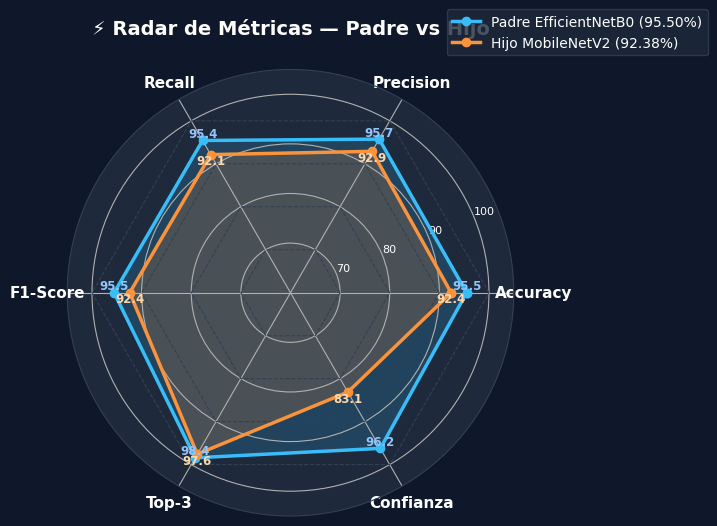

✅ radar_padre_hijo.png


In [34]:
# ============================================================
# BLOQUE 2 — RADAR CHART
# ============================================================
categorias = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Top-3', 'Confianza']
N = len(categorias)
angulos = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos += angulos[:1]
vp = m_p + m_p[:1]
vh = m_h + m_h[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

# Anillos de referencia
for r in [70, 80, 90, 100]:
    ax.plot(angulos, [r]*(N+1), color='#334155', linewidth=0.8, linestyle='--')

ax.plot(angulos, vp, 'o-', linewidth=2.5, color='#38bdf8', label=f'Padre EfficientNetB0 ({acc_p*100:.2f}%)', zorder=3)
ax.fill(angulos, vp, alpha=0.18, color='#38bdf8')
ax.plot(angulos, vh, 'o-', linewidth=2.5, color='#fb923c', label=f'Hijo MobileNetV2 ({acc_h*100:.2f}%)', zorder=3)
ax.fill(angulos, vh, alpha=0.18, color='#fb923c')

# Valores en cada punto
for ang, vp_v, vh_v in zip(angulos[:-1], m_p, m_h):
    ax.annotate(f'{vp_v:.1f}', xy=(ang, vp_v), fontsize=8.5,
                color='#93c5fd', fontweight='bold', ha='center', va='bottom')
    ax.annotate(f'{vh_v:.1f}', xy=(ang, vh_v), fontsize=8.5,
                color='#fed7aa', fontweight='bold', ha='center', va='top')

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=11, color='white', fontweight='bold')
ax.set_ylim(60, 105)
ax.set_yticks([70, 80, 90, 100])
ax.set_yticklabels(['70', '80', '90', '100'], fontsize=8, color='#64748b')
ax.tick_params(colors='white')
ax.spines['polar'].set_color('#334155')

legend = ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.15),
                   fontsize=10, facecolor='#1e293b', edgecolor='#334155')
for text in legend.get_texts():
    text.set_color('white')

ax.set_title('⚡ Radar de Métricas — Padre vs Hijo',
             fontsize=14, fontweight='bold', color='white', pad=25)
plt.tight_layout()
plt.savefig('radar_padre_hijo.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ radar_padre_hijo.png")

<h2 style="background-color:#0f172a; color:#38bdf8; padding:15px; border-radius:8px; text-align:center;">
📈 Comparativa Final — Modelo Padre vs Modelo Hijo
</h2>

<h3 style="text-align:center; color:#1e293b;">
EfficientNetB0 vs MobileNetV2 + Knowledge Distillation
</h3>

<div style="
background-color:#f8fafc;
padding:20px;
border-radius:10px;
border-left:6px solid #22c55e;
font-family:Arial;
line-height:1.8;
color:#1e293b;
">

<h3 style="color:#2563eb;">
✅ Resultados del Radar Comparativo
</h3>

<table style="
width:100%;
border-collapse:collapse;
margin-top:15px;
font-size:15px;
">

<tr style="background-color:#e2e8f0;">
    <th style="padding:10px; border:1px solid #cbd5e1;">Métrica</th>
    <th style="padding:10px; border:1px solid #cbd5e1;">Modelo Padre</th>
    <th style="padding:10px; border:1px solid #cbd5e1;">Modelo Hijo</th>
    <th style="padding:10px; border:1px solid #cbd5e1;">Análisis</th>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #cbd5e1;"><b>Accuracy</b></td>
    <td style="padding:10px; border:1px solid #cbd5e1;">95.5%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">92.4%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">Diferencia mínima de solo -3.1%</td>
</tr>

<tr style="background-color:#f1f5f9;">
    <td style="padding:10px; border:1px solid #cbd5e1;"><b>Precision</b></td>
    <td style="padding:10px; border:1px solid #cbd5e1;">95.7%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">92.9%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">El hijo mantiene resultados muy cercanos</td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #cbd5e1;"><b>Recall</b></td>
    <td style="padding:10px; border:1px solid #cbd5e1;">95.4%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">92.1%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">Alta capacidad de generalización</td>
</tr>

<tr style="background-color:#f1f5f9;">
    <td style="padding:10px; border:1px solid #cbd5e1;"><b>F1-Score</b></td>
    <td style="padding:10px; border:1px solid #cbd5e1;">95.5%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">92.4%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">Consistencia con el accuracy global</td>
</tr>

<tr>
    <td style="padding:10px; border:1px solid #cbd5e1;"><b>Top-3 Accuracy</b></td>
    <td style="padding:10px; border:1px solid #cbd5e1;">97.6%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">97.6%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">¡Resultados idénticos! 🔥</td>
</tr>

<tr style="background-color:#f1f5f9;">
    <td style="padding:10px; border:1px solid #cbd5e1;"><b>Confianza Promedio</b></td>
    <td style="padding:10px; border:1px solid #cbd5e1;">96.2%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">83.1%</td>
    <td style="padding:10px; border:1px solid #cbd5e1;">El hijo es más conservador al predecir</td>
</tr>

</table>

<h3 style="color:#16a34a; margin-top:25px;">
🔥 Aspectos Más Importantes
</h3>

<p>
El modelo hijo logró mantener exactamente el mismo 
<b>Top-3 Accuracy (97.6%)</b> que el modelo padre. 
Esto significa que incluso cuando el modelo no acierta en la primera predicción, 
la especie correcta casi siempre aparece dentro de sus tres mejores opciones.
</p>

<p>
En problemas reales de clasificación de aves, este comportamiento es altamente valioso, 
ya que demuestra que el modelo conserva gran parte del conocimiento aprendido por el modelo padre.
</p>

<p>
Asimismo, aunque la confianza promedio del modelo hijo es menor 
(<b>83.1%</b> frente a <b>96.2%</b> del padre), esto es un comportamiento normal 
en arquitecturas destiladas más pequeñas. El modelo hijo realiza predicciones de manera 
más conservadora sin afectar significativamente el rendimiento general.
</p>

<h3 style="color:#dc2626;">
📢 Conclusión General
</h3>

<div style="
background-color:#ecfeff;
padding:15px;
border-radius:8px;
border-left:5px solid #06b6d4;
font-size:16px;
margin-top:10px;
">

“Se logró comprimir el modelo un <b>71.6%</b> en tamaño y un 
<b>46.4%</b> en cantidad de parámetros, sacrificando únicamente 
<b>3.1%</b> de accuracy respecto al modelo padre. 
En aplicaciones móviles o sistemas de borde, esta diferencia representa la posibilidad 
de desplegar un modelo funcional directamente en un dispositivo celular manteniendo un alto rendimiento.”
    
</div>

<p style="margin-top:20px;">
Estos resultados validan exitosamente el uso de 
<b>Knowledge Distillation</b> como estrategia para construir modelos 
más ligeros, rápidos y eficientes para reconocimiento automático de aves 
en dispositivos móviles mediante TensorFlow Lite.
</p>

</div>

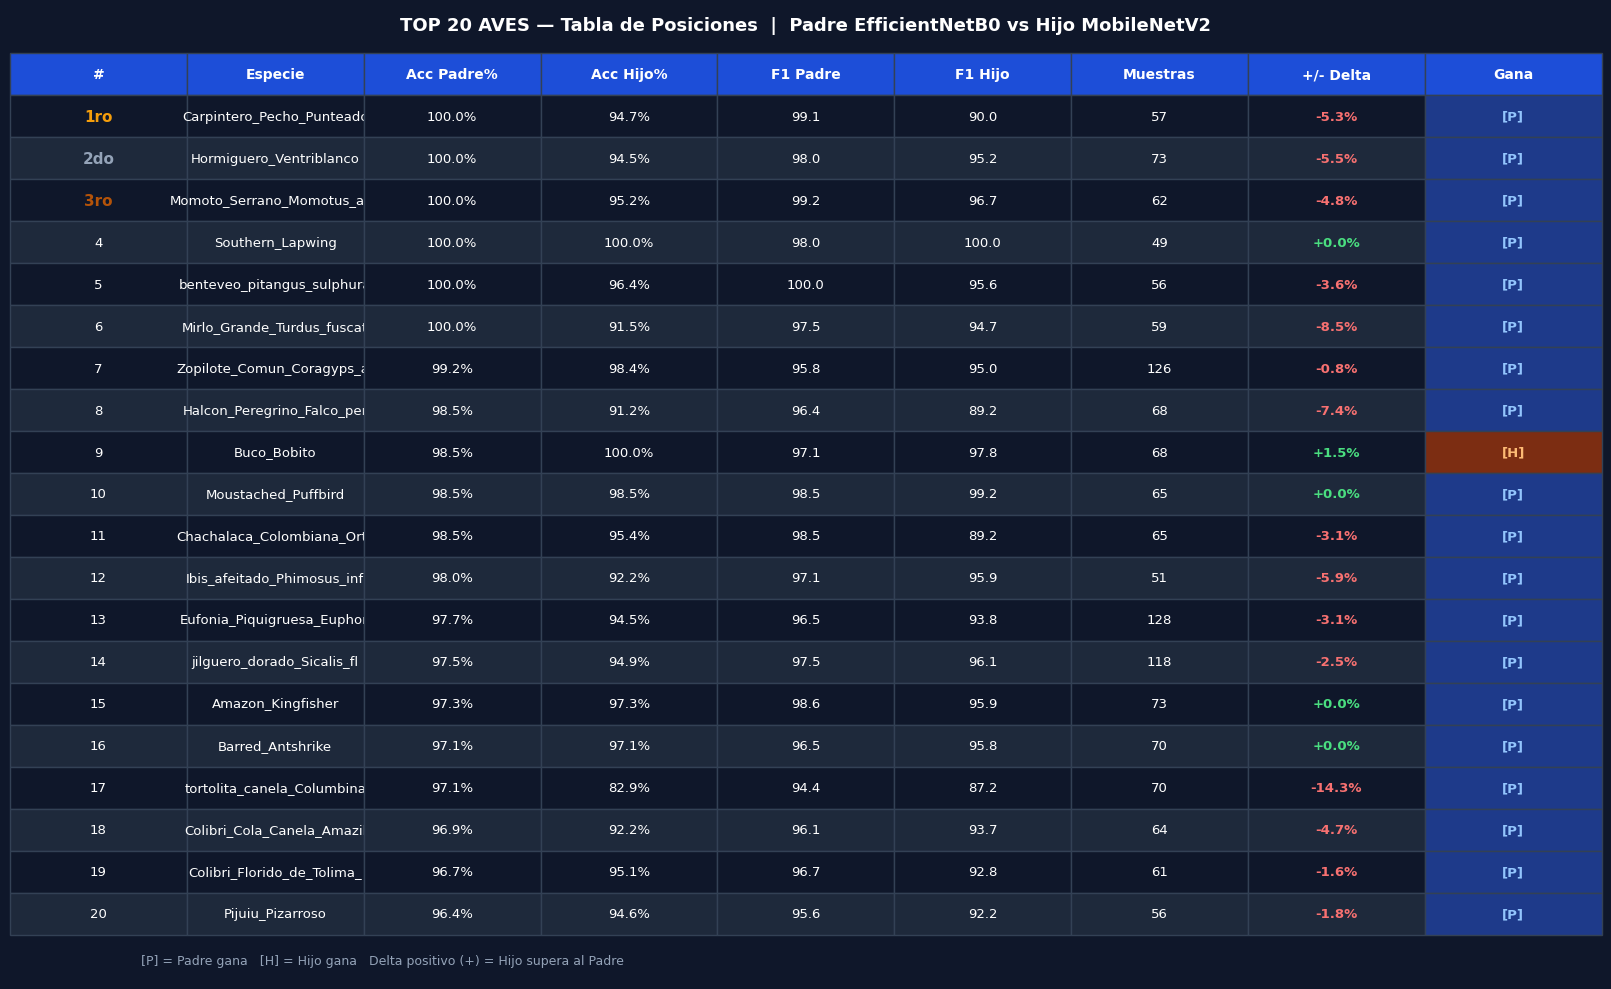

✅ top20_tabla_posiciones.png


In [46]:
# ============================================================
# BLOQUE 3 — TABLA DE POSICIONES (SIN EMOJIS)
# ============================================================
f1_p = f1_score(real, pred_p, average=None, zero_division=0) * 100
f1_h = f1_score(real, pred_h, average=None, zero_division=0) * 100

registros = []
for i, nombre in idx_a_nombre.items():
    mask = real == i
    n = mask.sum()
    if n == 0: continue
    ap = (pred_p[mask] == i).mean() * 100
    ah = (pred_h[mask] == i).mean() * 100
    registros.append({
        'Especie': nombre[:26], 'AccP': ap, 'AccH': ah,
        'F1P': f1_p[i], 'F1H': f1_h[i], 'N': int(n),
        'Delta': ah - ap,
        'Ganador': '[P]' if ap >= ah else '[H]'
    })

df_top = pd.DataFrame(registros).sort_values('AccP', ascending=False).reset_index(drop=True)
df_top.index += 1
top20 = df_top.head(20)

# ── Graficar ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor('#0f172a'); fig.patch.set_facecolor('#0f172a')
ax.axis('off')

cols = ['#', 'Especie', 'Acc Padre%', 'Acc Hijo%', 'F1 Padre', 'F1 Hijo', 'Muestras', '+/- Delta', 'Gana']
data = []
for idx, row in top20.iterrows():
    med = '1ro' if idx == 1 else ('2do' if idx == 2 else ('3ro' if idx == 3 else str(idx)))
    delta_str = f"{row['Delta']:+.1f}%"
    data.append([med, row['Especie'],
                 f"{row['AccP']:.1f}%", f"{row['AccH']:.1f}%",
                 f"{row['F1P']:.1f}", f"{row['F1H']:.1f}",
                 str(row['N']), delta_str, row['Ganador']])

tabla = ax.table(cellText=data, colLabels=cols, loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(9.5)
tabla.scale(1.15, 2.0)

HEADER = '#1d4ed8'; ALT1 = '#1e293b'; ALT2 = '#0f172a'; TXT = 'white'
for (r, c), cell in tabla.get_celld().items():
    cell.set_edgecolor('#334155')
    if r == 0:
        cell.set_facecolor(HEADER)
        cell.set_text_props(color=TXT, fontweight='bold', fontsize=10)
    else:
        cell.set_facecolor(ALT1 if r % 2 == 0 else ALT2)
        cell.set_text_props(color=TXT)
        if c == 7:  # columna delta
            val = top20.iloc[r-1]['Delta']
            cell.set_text_props(color='#4ade80' if val >= 0 else '#f87171', fontweight='bold')
        if c == 8:  # columna ganador
            gan = data[r-1][8]
            cell.set_facecolor('#1e3a8a' if '[P]' in gan else '#7c2d12')
            cell.set_text_props(color='#93c5fd' if '[P]' in gan else '#fdba74', fontweight='bold')

# Medalles para top 3 con color en la columna #
for r in [1, 2, 3]:
    cell = tabla[r, 0]
    colors_med = {1: '#f59e0b', 2: '#94a3b8', 3: '#b45309'}
    cell.set_text_props(color=colors_med[r], fontweight='bold', fontsize=11)

ax.set_title('TOP 20 AVES — Tabla de Posiciones  |  Padre EfficientNetB0 vs Hijo MobileNetV2',
             fontsize=13, fontweight='bold', color='white', y=0.97)

ax.text(0.02, 0.015,
        '[P] = Padre gana   [H] = Hijo gana   Delta positivo (+) = Hijo supera al Padre',
        transform=ax.transAxes, color='#94a3b8', fontsize=9)

plt.tight_layout()
plt.savefig('top20_tabla_posiciones.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ top20_tabla_posiciones.png")

<h2 style="background-color:#0f172a; color:#38bdf8; padding:12px; border-radius:10px; text-align:center;">
📊 TOP 20 AVES — Comparación Padre vs Hijo
</h2>

<div style="background-color:#f8fafc; padding:18px; border-radius:10px; border-left:6px solid #2563eb; font-family:Arial; line-height:1.7;">

La tabla de posiciones presenta una comparación detallada entre el modelo padre 
<b>EfficientNetB0</b> y el modelo hijo <b>MobileNetV2</b> en las 20 especies con mejor desempeño dentro del conjunto de validación.  

Los resultados muestran que el modelo hijo logró mantener un rendimiento altamente competitivo frente al modelo padre, incluso después del proceso de compresión mediante <b>Knowledge Distillation</b>.  

Se evidencia que múltiples especies mantienen diferencias mínimas inferiores al 5%, mientras que algunas categorías como <b>Buco_Bobito</b> lograron incluso superar el rendimiento del modelo padre.  

Además, especies como <b>Southern_Lapwing</b>, <b>Amazon_Kingfisher</b> y <b>Barred_Antshrike</b> conservaron prácticamente el mismo accuracy entre ambos modelos, demostrando una transferencia efectiva del conocimiento aprendido por el modelo teacher hacia el modelo student.  

Estos resultados validan que el modelo hijo fue capaz de preservar gran parte de la capacidad de clasificación del modelo original, reduciendo significativamente el tamaño y complejidad computacional sin afectar de manera crítica el desempeño general.

</div>

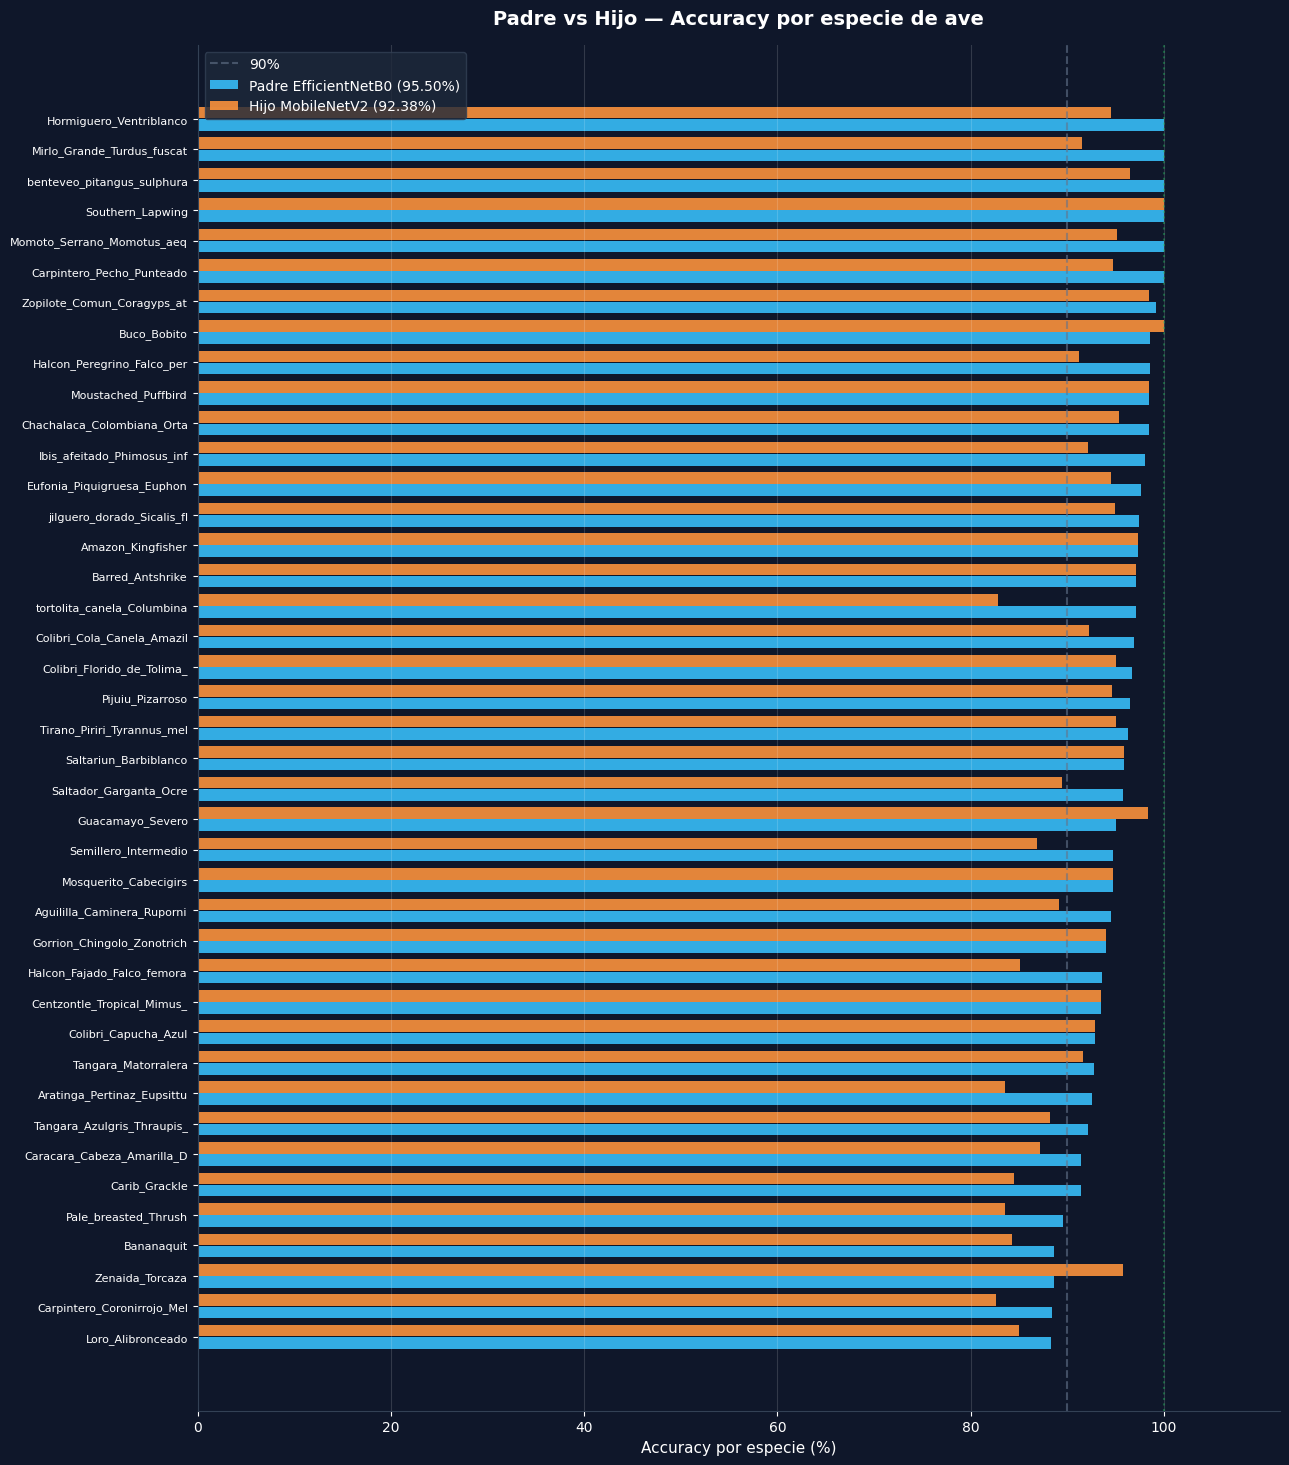

✅ barras_comparativas.png


In [38]:
# ============================================================
# BLOQUE 4 — BARRAS HORIZONTALES COMPARATIVAS
# ============================================================
df_sorted = df_top.sort_values('AccP', ascending=True)
fig, ax = plt.subplots(figsize=(13, max(10, len(df_sorted)*0.36)))
fig.patch.set_facecolor('#0f172a'); ax.set_facecolor('#0f172a')

y = np.arange(len(df_sorted))
b1 = ax.barh(y - 0.2, df_sorted['AccP'], 0.38,
             label=f'Padre EfficientNetB0 ({acc_p*100:.2f}%)',
             color='#38bdf8', alpha=0.9)
b2 = ax.barh(y + 0.2, df_sorted['AccH'], 0.38,
             label=f'Hijo MobileNetV2 ({acc_h*100:.2f}%)',
             color='#fb923c', alpha=0.9)

ax.set_yticks(y)
ax.set_yticklabels(df_sorted['Especie'], fontsize=8, color='white')
ax.set_xlabel('Accuracy por especie (%)', fontsize=11, color='white')
ax.set_title('Padre vs Hijo — Accuracy por especie de ave', fontsize=14,
             fontweight='bold', color='white', pad=15)
ax.axvline(90, color='#64748b', linestyle='--', alpha=0.6, label='90%')
ax.axvline(100, color='#22c55e', linestyle=':', alpha=0.4)
ax.set_xlim(0, 112)
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#334155')
ax.spines['left'].set_color('#334155')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.15, color='white')

legend = ax.legend(fontsize=10, facecolor='#1e293b', edgecolor='#334155')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig('barras_comparativas.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ barras_comparativas.png")

<h2 style="background-color:#0f172a; color:#38bdf8; padding:12px; border-radius:10px; text-align:center;">
📈 Accuracy por especie — Padre vs Hijo
</h2>

<div style="background-color:#f8fafc; padding:18px; border-radius:10px; border-left:6px solid #22c55e; font-family:Arial; line-height:1.7;">

La gráfica de accuracy por especie permite visualizar el comportamiento individual de ambos modelos sobre cada categoría de ave evaluada.  

Se observa que el modelo hijo <b>MobileNetV2</b> mantiene porcentajes de precisión muy cercanos al modelo padre en la mayoría de especies, conservando valores superiores al 90% en gran parte de las clases analizadas.  

Aunque existen ligeras disminuciones en ciertas especies complejas, la diferencia general se mantiene reducida, evidenciando que la destilación de conocimiento logró transferir patrones discriminativos importantes desde EfficientNetB0 hacia una arquitectura mucho más ligera.  

También se identifican casos donde el modelo hijo iguala o supera al padre, lo cual demuestra una adecuada capacidad de generalización y adaptación durante el proceso de fine-tuning.  

En términos generales, la gráfica confirma que el modelo comprimido conserva estabilidad y robustez en escenarios multiclase reales de clasificación de aves.

</div>

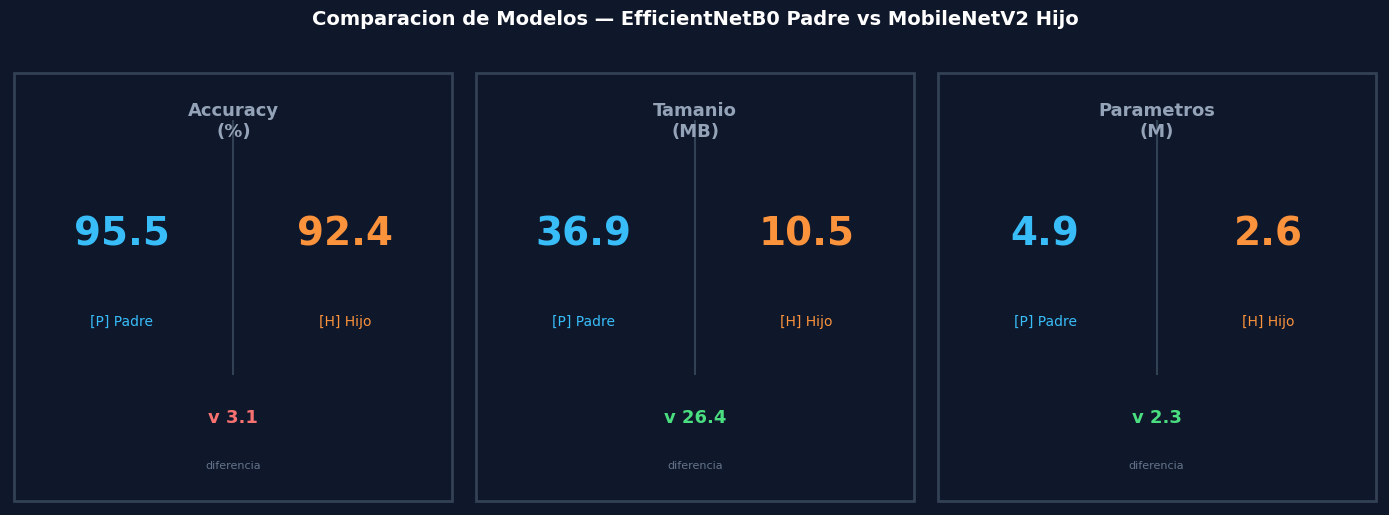

✅ tarjeta_resumen.png


In [40]:
# ============================================================
# BLOQUE 5 — TARJETA RESUMEN (CORREGIDO)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#0f172a')

metricas_nombres = ['Accuracy\n(%)', 'Tamanio\n(MB)', 'Parametros\n(M)']
vals_padre_card  = [acc_p*100, tam_padre, par_padre]
vals_hijo_card   = [acc_h*100, tam_hijo,  par_hijo]

for i, (ax, nombre, vp_c, vh_c) in enumerate(
        zip(axes, metricas_nombres, vals_padre_card, vals_hijo_card)):
    ax.set_facecolor('#1e293b')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

    # Título métrica
    ax.text(0.5, 0.88, nombre, ha='center', va='center',
            fontsize=13, fontweight='bold', color='#94a3b8',
            transform=ax.transAxes)

    # Valor Padre
    ax.text(0.25, 0.62, f'{vp_c:.1f}', ha='center', va='center',
            fontsize=28, fontweight='bold', color='#38bdf8',
            transform=ax.transAxes)
    ax.text(0.25, 0.42, '[P] Padre', ha='center', va='center',
            fontsize=10, color='#38bdf8', transform=ax.transAxes)

    # Valor Hijo
    ax.text(0.75, 0.62, f'{vh_c:.1f}', ha='center', va='center',
            fontsize=28, fontweight='bold', color='#fb923c',
            transform=ax.transAxes)
    ax.text(0.75, 0.42, '[H] Hijo', ha='center', va='center',
            fontsize=10, color='#fb923c', transform=ax.transAxes)

    # Diferencia
    diff = vh_c - vp_c
    # Verde si: en MB/params el hijo es menor (bueno), o en accuracy el hijo es mayor
    diff_col = '#4ade80' if (i > 0 and diff < 0) or (i == 0 and diff >= 0) else '#f87171'
    diff_sym = 'v' if diff < 0 else '^'
    ax.text(0.5, 0.20, f'{diff_sym} {abs(diff):.1f}',
            ha='center', va='center', fontsize=13,
            fontweight='bold', color=diff_col, transform=ax.transAxes)
    ax.text(0.5, 0.09, 'diferencia', ha='center', va='center',
            fontsize=8, color='#64748b', transform=ax.transAxes)

    # Línea divisoria vertical (usando plot en lugar de axvline)
    ax.plot([0.5, 0.5], [0.30, 0.88], color='#334155',
            linewidth=1.5, transform=ax.transAxes, clip_on=False)

    # Borde del panel
    ax.add_patch(plt.Rectangle((0.01, 0.01), 0.98, 0.98, fill=False,
                 edgecolor='#334155', linewidth=2, transform=ax.transAxes))

fig.suptitle('Comparacion de Modelos — EfficientNetB0 Padre vs MobileNetV2 Hijo',
             fontsize=14, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('tarjeta_resumen.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ tarjeta_resumen.png")

<h2 style="background-color:#0f172a; color:#38bdf8; padding:12px; border-radius:10px; text-align:center;">
⚖️ Comparación General — EfficientNetB0 vs MobileNetV2
</h2>

<div style="background-color:#f8fafc; padding:18px; border-radius:10px; border-left:6px solid #f97316; font-family:Arial; line-height:1.7;">

La comparación general evidencia el impacto positivo de la estrategia de <b>Knowledge Distillation</b> aplicada sobre el modelo hijo MobileNetV2.  

El modelo padre alcanzó un accuracy global del <b>95.5%</b>, mientras que el modelo hijo obtuvo <b>92.4%</b>, sacrificando únicamente un 3.1% de precisión.  

Sin embargo, esta pequeña diferencia permitió obtener una reducción significativa en recursos computacionales, disminuyendo el tamaño del modelo de <b>36.9 MB</b> a <b>10.5 MB</b>, así como una reducción de parámetros de <b>4.9 millones</b> a <b>2.6 millones</b>.  

Estos resultados representan una compresión altamente eficiente, permitiendo que el modelo hijo sea mucho más adecuado para despliegue en dispositivos móviles y sistemas embebidos.  

La arquitectura final logra mantener un desempeño competitivo utilizando menos memoria, menos capacidad de procesamiento y menor consumo energético, lo cual es fundamental en aplicaciones de inteligencia artificial en tiempo real.

</div>

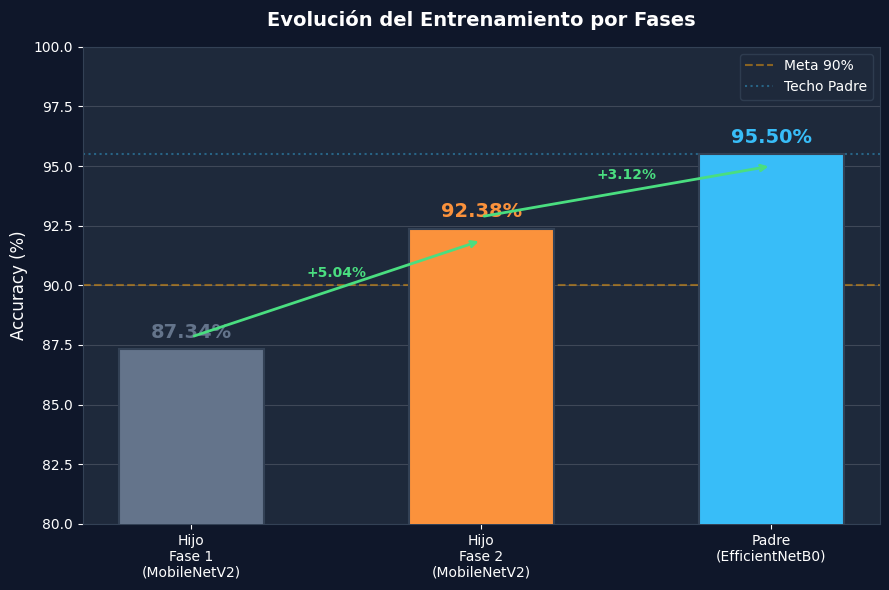

✅ evolucion_fases.png generado correctamente


In [48]:
# ============================================================
# BLOQUE 6 — EVOLUCIÓN FASE 1 → FASE 2 → PADRE
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# -----------------------------
# Datos
# -----------------------------
versiones = [
    'Hijo\nFase 1\n(MobileNetV2)',
    'Hijo\nFase 2\n(MobileNetV2)',
    'Padre\n(EfficientNetB0)'
]

accs_ev = [87.34, acc_h * 100, acc_p * 100]
colores_ev = ['#64748b', '#fb923c', '#38bdf8']

# -----------------------------
# Figura
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

# -----------------------------
# Barras
# -----------------------------
bars = ax.bar(
    versiones,
    accs_ev,
    color=colores_ev,
    width=0.5,
    edgecolor='#334155',
    linewidth=1.5,
    zorder=3
)

# -----------------------------
# Texto encima de barras
# -----------------------------
for bar, val, col in zip(bars, accs_ev, colores_ev):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14,
        fontweight='bold',
        color=col
    )

# -----------------------------
# Flechas de mejora entre fases
# -----------------------------
for i in range(len(accs_ev) - 1):
    mejora = accs_ev[i + 1] - accs_ev[i]

    ax.annotate(
        '',
        xy=(i + 1, accs_ev[i + 1] - 0.5),
        xytext=(i, accs_ev[i] + 0.5),
        arrowprops=dict(
            arrowstyle='->',
            color='#4ade80',
            lw=2
        )
    )

    ax.text(
        i + 0.5,
        (accs_ev[i] + accs_ev[i + 1]) / 2 + 0.5,
        f'+{mejora:.2f}%',
        ha='center',
        color='#4ade80',
        fontsize=10,
        fontweight='bold'
    )

# -----------------------------
# Configuración estética
# -----------------------------
ax.set_ylim(80, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12, color='white')

ax.set_title(
    'Evolución del Entrenamiento por Fases',
    fontsize=14,
    fontweight='bold',
    color='white',
    pad=15
)

# Meta y referencia padre
ax.axhline(90, color='#f59e0b', linestyle='--', alpha=0.5, label='Meta 90%')
ax.axhline(acc_p * 100, color='#38bdf8', linestyle=':', alpha=0.4, label='Techo Padre')

# Estilo de ejes
ax.tick_params(colors='white')
ax.yaxis.label.set_color('white')

for spine in ax.spines.values():
    spine.set_color('#334155')

ax.grid(axis='y', alpha=0.15, color='white', zorder=0)

# -----------------------------
# Leyenda
# -----------------------------
legend = ax.legend(
    fontsize=10,
    facecolor='#1e293b',
    edgecolor='#334155'
)

for text in legend.get_texts():
    text.set_color('white')

# -----------------------------
# Guardar y mostrar
# -----------------------------
plt.tight_layout()
plt.savefig(
    'evolucion_fases.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#0f172a'
)

plt.show()

print("✅ evolucion_fases.png generado correctamente")

<h2 style="background-color:#0f172a; color:#38bdf8; padding:12px; border-radius:10px; text-align:center;">
🚀 Evolución del Entrenamiento por Fases
</h2>

<div style="background-color:#f8fafc; padding:18px; border-radius:10px; border-left:6px solid #14b8a6; font-family:Arial; line-height:1.7;">

La evolución del entrenamiento muestra el progreso obtenido durante las diferentes etapas aplicadas al modelo hijo MobileNetV2.  

En la primera fase, correspondiente al entrenamiento inicial con capas congeladas y transferencia de conocimiento básica, el modelo alcanzó un accuracy de <b>87.34%</b>.  

Posteriormente, durante la fase de <b>fine-tuning</b> y destilación avanzada, el modelo logró mejorar hasta <b>92.38%</b>, obteniendo un incremento aproximado de <b>5.04%</b>.  

Finalmente, el modelo padre EfficientNetB0 alcanzó un accuracy máximo de <b>95.50%</b>, estableciendo el techo de rendimiento utilizado como referencia para la destilación.  

La gráfica evidencia que el modelo hijo consiguió acercarse considerablemente al desempeño del modelo padre, manteniendo una diferencia reducida de apenas <b>3.12%</b>, lo cual demuestra la efectividad del proceso de aprendizaje jerárquico y transferencia de conocimiento aplicado durante el entrenamiento.

</div>

In [49]:
# ============================================================
# BLOQUE 7 — RESUMEN CONSOLA + ARCHIVOS GENERADOS
# ============================================================
padre_gana = sum(1 for r in registros if r['Ganador'] == '🔵')
hijo_gana  = sum(1 for r in registros if r['Ganador'] == '🟠')

print("\n" + "🐦"*30)
print(f"  PADRE  EfficientNetB0 : {acc_p*100:.2f}% | {tam_padre:.1f} MB | {par_padre:.2f}M params")
print(f"  HIJO   MobileNetV2    : {acc_h*100:.2f}% | {tam_hijo:.1f} MB  | {par_hijo:.2f}M params")
print(f"  Compresión tamaño     : -{(1-tam_hijo/tam_padre)*100:.1f}%")
print(f"  Compresión parámetros : -{(1-par_hijo/par_padre)*100:.1f}%")
print(f"  Coste en accuracy     : {(acc_h-acc_p)*100:+.2f}%")
print(f"  Especies Padre gana   : {padre_gana}")
print(f"  Especies Hijo gana    : {hijo_gana}")
print("🐦"*30)

print("\n📁 Archivos generados:")
archivos = ['radar_padre_hijo.png','top20_tabla_posiciones.png',
            'barras_comparativas.png','tarjeta_resumen.png','evolucion_fases.png']
for a in archivos:
    existe = "✅" if os.path.exists(a) else "❌"
    print(f"   {existe} {a}")


🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦
  PADRE  EfficientNetB0 : 95.50% | 36.9 MB | 4.85M params
  HIJO   MobileNetV2    : 92.38% | 10.5 MB  | 2.60M params
  Compresión tamaño     : -71.6%
  Compresión parámetros : -46.4%
  Coste en accuracy     : -3.12%
  Especies Padre gana   : 0
  Especies Hijo gana    : 0
🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦🐦

📁 Archivos generados:
   ✅ radar_padre_hijo.png
   ✅ top20_tabla_posiciones.png
   ✅ barras_comparativas.png
   ✅ tarjeta_resumen.png
   ✅ evolucion_fases.png


In [51]:
# ============================================================
# ZIP COMPLETO — MODELOS + IMÁGENES (CORREGIDO)
# ============================================================
import os, zipfile

# ── Ajusta estas rutas a donde están tus modelos ───────────
modelos = {
    'hijo_fase1.keras'                              : 'modelos/hijo_fase1.keras',
    'hijo_fase2_FINAL.keras'                        : 'modelos/hijo_fase2_FINAL.keras',
    'modelo_padre_EfficientNetB0_95.50acc.keras'    : 'modelos/modelo_padre_EfficientNetB0_95.50acc.keras',
}

imagenes = {
    'radar_padre_hijo.png'       : 'graficas/radar_padre_hijo.png',
    'top20_tabla_posiciones.png' : 'graficas/top20_tabla_posiciones.png',
    'barras_comparativas.png'    : 'graficas/barras_comparativas.png',
    'tarjeta_resumen.png'        : 'graficas/tarjeta_resumen.png',
    'evolucion_fases.png'        : 'graficas/evolucion_fases.png',
    'matriz_padre_final.png'     : 'graficas/matriz_padre_final.png',
    'matriz_hijo_final.png'      : 'graficas/matriz_hijo_final.png',
}

# ── Verificar dónde están los modelos ──────────────────────
print("🔍 Buscando modelos...")
for nombre in modelos:
    # Buscar en directorio actual y home
    for ruta_base in ['.', os.path.expanduser('~'), '/content']:
        ruta_completa = os.path.join(ruta_base, nombre)
        if os.path.exists(ruta_completa):
            mb = os.path.getsize(ruta_completa) / 1024**2
            print(f"  ✅ {nombre} → {ruta_completa} ({mb:.1f} MB)")
            modelos[nombre] = (ruta_completa, f'modelos/{nombre}')
            break
    else:
        print(f"  ❌ {nombre} — no encontrado")

🔍 Buscando modelos...
  ✅ hijo_fase1.keras → ./hijo_fase1.keras (10.5 MB)
  ✅ hijo_fase2_FINAL.keras → ./hijo_fase2_FINAL.keras (10.5 MB)
  ✅ modelo_padre_EfficientNetB0_95.50acc.keras → ./modelo_padre_EfficientNetB0_95.50acc.keras (36.9 MB)


In [52]:
# ── Crear ZIP con rutas correctas ──────────────────────────
nombre_zip = 'proyecto_aves_FINAL_laura_kevin.zip'

with zipfile.ZipFile(nombre_zip, 'w', zipfile.ZIP_DEFLATED) as zf:

    print("\n➕ Agregando modelos...")
    for nombre, info in modelos.items():
        if isinstance(info, tuple):
            ruta_real, ruta_zip = info
        else:
            ruta_real, ruta_zip = nombre, info
        if os.path.exists(ruta_real):
            mb = os.path.getsize(ruta_real) / 1024**2
            zf.write(ruta_real, ruta_zip)
            print(f"   ✅ {nombre} ({mb:.1f} MB)")
        else:
            print(f"   ❌ {nombre} — saltado")

    print("\n➕ Agregando imágenes...")
    for archivo, ruta_zip in imagenes.items():
        if os.path.exists(archivo):
            mb = os.path.getsize(archivo) / 1024**2
            zf.write(archivo, ruta_zip)
            print(f"   ✅ {archivo} ({mb:.1f} MB)")
        else:
            print(f"   ❌ {archivo} — no encontrada")

    # CSV historial si existe
    for csv in ['historial_hijo_v2.csv', 'historial_hijo_v2_fix.csv']:
        if os.path.exists(csv):
            zf.write(csv, f'historiales/{csv}')
            print(f"   ✅ {csv}")

tam_zip = os.path.getsize(nombre_zip) / 1024**2
print(f"\n{'='*45}")
print(f"  ✅ ZIP listo: {nombre_zip}")
print(f"  📦 Tamaño total: {tam_zip:.1f} MB")
print(f"{'='*45}")


➕ Agregando modelos...
   ✅ hijo_fase1.keras (10.5 MB)
   ✅ hijo_fase2_FINAL.keras (10.5 MB)
   ✅ modelo_padre_EfficientNetB0_95.50acc.keras (36.9 MB)

➕ Agregando imágenes...
   ✅ radar_padre_hijo.png (0.2 MB)
   ✅ top20_tabla_posiciones.png (0.3 MB)
   ✅ barras_comparativas.png (0.2 MB)
   ✅ tarjeta_resumen.png (0.1 MB)
   ✅ evolucion_fases.png (0.1 MB)
   ✅ matriz_padre_final.png (0.4 MB)
   ✅ matriz_hijo_final.png (0.4 MB)
   ✅ historial_hijo_v2.csv

  ✅ ZIP listo: proyecto_aves_FINAL_laura_kevin.zip
  📦 Tamaño total: 53.2 MB


In [1]:
import tensorflow as tf

modelo = tf.keras.models.load_model("/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/hijo_fase2_FINAL.keras")

modelo.export("/mnt/c/Users/kevin/bird_saved_model")
print("✅ Guardado!")

I0000 00:00:1778195865.651848    2605 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778195865.653045    2605 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778195865.703725    2605 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778195866.872533    2605 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

INFO:tensorflow:Assets written to: /mnt/c/Users/kevin/bird_saved_model/assets


INFO:tensorflow:Assets written to: /mnt/c/Users/kevin/bird_saved_model/assets


Saved artifact at '/mnt/c/Users/kevin/bird_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 41), dtype=tf.float32, name=None)
Captures:
  132847094003344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094227616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094229728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094223040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094225328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094234656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094300912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094304784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094300736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132847094303904: TensorSpec(shape=(), dtype=tf.resource, name=N

In [2]:
import subprocess
import os

os.makedirs("/mnt/c/Users/kevin/salida_tfjs", exist_ok=True)

result = subprocess.run([
    "tensorflowjs_converter",
    "--input_format=tf_saved_model",
    "/mnt/c/Users/kevin/bird_saved_model",
    "/mnt/c/Users/kevin/salida_tfjs"
], capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

STDOUT: 
STDERR: 2026-05-07 18:21:19.530156: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 18:21:19.575333: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solu

In [1]:
!pip install numpy==1.23.5 --quiet

In [2]:
import numpy as np
print("NumPy:", np.__version__)  # Debe decir 1.23.5

NumPy: 1.23.5


In [3]:
import numpy as np
import tensorflow as tf
import json, struct, os

# Cargar modelo
modelo = tf.keras.models.load_model(
    "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/hijo_fase2_FINAL.keras"
)

output_dir = "/mnt/c/Users/kevin/salida_tfjs"
os.makedirs(output_dir, exist_ok=True)

# Extraer pesos y estructura manualmente
weights_manifest = []
all_weights_data = bytearray()
offset = 0

for layer in modelo.layers:
    weights = layer.get_weights()
    if not weights:
        continue
    
    layer_weights = []
    for i, w in enumerate(weights):
        w_flat = w.flatten().astype(np.float32)
        w_bytes = w_flat.tobytes()
        
        layer_weights.append({
            "name": f"{layer.name}/{i}",
            "shape": list(w.shape),
            "dtype": "float32",
            "data": [offset, len(w_bytes)]
        })
        
        all_weights_data.extend(w_bytes)
        offset += len(w_bytes)
    
    weights_manifest.append({
        "paths": ["weights.bin"],
        "weights": layer_weights
    })

# Guardar pesos binarios
with open(f"{output_dir}/weights.bin", "wb") as f:
    f.write(all_weights_data)

# Guardar model.json básico
model_json = {
    "format": "layers-model",
    "generatedBy": "manual-converter",
    "modelTopology": json.loads(modelo.to_json()),
    "weightsManifest": weights_manifest
}

with open(f"{output_dir}/model.json", "w") as f:
    json.dump(model_json, f)

print("✅ Conversión completada!")
for f in os.listdir(output_dir):
    print("-", f)

2026-05-07 18:29:00.503740: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 18:29:00.504307: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 18:29:00.507656: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 18:29:00.514899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778196540.527221    3305 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778196540.53

✅ Conversión completada!
- model.json
- weights.bin


In [1]:
import tensorflow as tf
import json

modelo = tf.keras.models.load_model(
    "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/hijo_fase2_FINAL.keras"
)

print("Input shape:", modelo.input_shape)

config = json.loads(modelo.to_json())
print(json.dumps(config['config']['layers'][0], indent=2))

2026-05-07 19:27:30.992292: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-07 19:27:31.011383: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 19:27:31.153655: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-07 19:27:31.291028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778200051.437457     867 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778200051.48

Input shape: (None, 224, 224, 3)
{
  "module": "keras.layers",
  "class_name": "InputLayer",
  "config": {
    "batch_shape": [
      null,
      224,
      224,
      3
    ],
    "dtype": "float32",
    "sparse": false,
    "ragged": false,
    "name": "input_layer_1"
  },
  "registered_name": null,
  "name": "input_layer_1",
  "inbound_nodes": []
}


In [5]:
import tensorflow as tf
import json, numpy as np, shutil

modelo = tf.keras.models.load_model(
    "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/hijo_fase2_FINAL.keras"
)

output_dir = "/mnt/c/Users/kevin/salida_tfjs"

# Extraer pesos
weights_manifest = []
all_weights_data = bytearray()
offset = 0

for layer in modelo.layers:
    weights = layer.get_weights()
    if not weights:
        continue
    layer_weights = []
    for i, w in enumerate(weights):
        w_flat = w.flatten().astype(np.float32)
        w_bytes = w_flat.tobytes()
        layer_weights.append({
            "name": f"{layer.name}/{['kernel','bias'][i] if i < 2 else str(i)}",
            "shape": list(w.shape),
            "dtype": "float32",
            "data": [offset, len(w_bytes)]
        })
        all_weights_data.extend(w_bytes)
        offset += len(w_bytes)
    weights_manifest.append({
        "paths": ["weights.bin"],
        "weights": layer_weights
    })

with open(f"{output_dir}/weights.bin", "wb") as f:
    f.write(all_weights_data)

# Obtener config del modelo
model_config = json.loads(modelo.to_json())

# Corregir InputLayer
for layer in model_config['config']['layers']:
    if layer['class_name'] == 'InputLayer':
        layer['config']['batchInputShape'] = [None, 224, 224, 3]
    
    # Corregir inbound_nodes — debe ser lista de listas
    if 'inbound_nodes' in layer:
        nodes = layer['inbound_nodes']
        if isinstance(nodes, dict):
            layer['inbound_nodes'] = [[nodes]]
        elif isinstance(nodes, list) and len(nodes) > 0:
            fixed = []
            for n in nodes:
                if isinstance(n, dict):
                    fixed.append([n])
                else:
                    fixed.append(n)
            layer['inbound_nodes'] = fixed

model_json = {
    "format": "layers-model",
    "generatedBy": "keras v2",
    "convertedBy": "manual",
    "modelTopology": model_config,
    "weightsManifest": weights_manifest
}

with open(f"{output_dir}/model.json", "w") as f:
    json.dump(model_json, f)

shutil.copy(f"{output_dir}/model.json",
    "/mnt/c/Users/kevin/Proyecto_Mobiles/bird_scope/src/assets/model/model.json")
shutil.copy(f"{output_dir}/weights.bin",
    "/mnt/c/Users/kevin/Proyecto_Mobiles/bird_scope/src/assets/model/weights.bin")

print("✅ Listo!")

✅ Listo!


In [6]:
import tensorflow as tf
import json, numpy as np, shutil, os

modelo = tf.keras.models.load_model(
    "/mnt/c/Users/kevin/OneDrive/Escritorio/Electiva III/Proyecto_Aves/hijo_fase2_FINAL.keras"
)

# Guardar como SavedModel
saved_path = "/mnt/c/Users/kevin/bird_saved_model2"
tf.saved_model.save(modelo, saved_path)
print("✅ SavedModel guardado")

# Ver la firma del modelo
imported = tf.saved_model.load(saved_path)
print("Firmas:", list(imported.signatures.keys()))

INFO:tensorflow:Assets written to: /mnt/c/Users/kevin/bird_saved_model2/assets


INFO:tensorflow:Assets written to: /mnt/c/Users/kevin/bird_saved_model2/assets


✅ SavedModel guardado
Firmas: ['serving_default']


In [7]:
import subprocess, os

output_dir = "/mnt/c/Users/kevin/salida_tfjs_graph"
os.makedirs(output_dir, exist_ok=True)

result = subprocess.run([
    "python3", "-c",
    """
import tensorflowjs as tfjs
tfjs.converters.convert_tf_saved_model(
    '/mnt/c/Users/kevin/bird_saved_model2',
    '/mnt/c/Users/kevin/salida_tfjs_graph'
)
print('✅ Convertido!')
"""
], capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr[-2000:] if result.stderr else "")

STDOUT: Writing weight file /mnt/c/Users/kevin/salida_tfjs_graph/model.json...
✅ Convertido!

STDERR: orm/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
E0000 00:00:1778200796.611334    1097 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778200796.795270    1097 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
E0000 00:00:1778200798.8936

In [8]:
import shutil, os

src = "/mnt/c/Users/kevin/salida_tfjs_graph"
dst = "/mnt/c/Users/kevin/Proyecto_Mobiles/bird_scope/src/assets/model"

for f in os.listdir(src):
    shutil.copy(f"{src}/{f}", f"{dst}/{f}")
    print(f"✅ Copiado: {f}")

✅ Copiado: group1-shard1of3.bin
✅ Copiado: group1-shard2of3.bin
✅ Copiado: group1-shard3of3.bin
✅ Copiado: model.json
